# 02_feature_engineering.ipynb — Feature Engineering for PISA 2022 Process Data Analysis

## Purpose
Transform the integrated raw dataset from 01_data_merging.ipynb into a student-level
analytic feature matrix suitable for non-linear machine learning and SHAP-based
interpretability analysis.

## Theoretical Framework
- **Dual-Process Theory** (Kahneman, 2011; Evans & Stanovich, 2013)
- **Self-Regulated Learning** (Zimmerman, 2000)
- **Cognitive Load Theory** (Sweller, 1988)
- **MSAT-aware process data analysis** (PISA 2022 specific, OECD 2024)

## Key Methodological Innovations
1. **Item-level standardisation** of response times (z-score within item) to remove
   MSAT routing confounding and CM/CMA item-family heterogeneity (see NB01 diagnostics)
2. **GMM-based System 1 probability** as primary dual-process indicator
3. **System 1 decomposition** into guessing vs heuristic sub-processes
4. **Dual tracking** of standardised and raw features for sensitivity analysis

## Inputs
- `data/analysis/pisa2022_ml_dataset.parquet` (613,744 × 1,201, from NB01)

## Outputs
- `data/analysis/pisa2022_features.parquet` — primary feature matrix for NB03
- `data/analysis/pisa2022_item_level.parquet` — per-item GMM diagnostics for thesis appendix
- `data/analysis/nb02_diagnostics/` — additional diagnostics (feature correlation, 
  outlier counts, standardisation sanity checks)

In [117]:
# Imports and environment setup

import os
import gc
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import psutil

from sklearn.mixture import GaussianMixture
from scipy import stats

warnings.filterwarnings("ignore")

# Display settings
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 200)

# Reproducibility (consistent with NB01)
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

# Memory utility
def print_memory():
    process = psutil.Process()
    mem_gb = process.memory_info().rss / (1024 ** 3)
    avail_gb = psutil.virtual_memory().available / (1024 ** 3)
    print(f"Current process memory: {mem_gb:.2f} GB | System RAM available: {avail_gb:.2f} GB")

print("Environment:")
print(f"  pandas         : {pd.__version__}")
print(f"  numpy          : {np.__version__}")
print(f"  scikit-learn   : {__import__('sklearn').__version__}")
print(f"  scipy          : {__import__('scipy').__version__}")
print(f"  Random seed    : {RANDOM_SEED}")
print_memory()

Environment:
  pandas         : 3.0.2
  numpy          : 2.4.4
  scikit-learn   : 1.8.0
  scipy          : 1.17.1
  Random seed    : 42
Current process memory: 1.46 GB | System RAM available: 4.87 GB


In [118]:
# Project paths

PROJECT_ROOT = Path.home() / "Desktop" / "PISA-Process-Data-Analysis"
DATA_ANALYSIS = PROJECT_ROOT / "data" / "analysis"

INPUT_PARQUET = DATA_ANALYSIS / "pisa2022_ml_dataset.parquet"
OUTPUT_FEATURES = DATA_ANALYSIS / "pisa2022_features.parquet"
OUTPUT_ITEM_LEVEL = DATA_ANALYSIS / "pisa2022_item_level.parquet"

NB02_DIAG_DIR = DATA_ANALYSIS / "nb02_diagnostics"
NB02_DIAG_DIR.mkdir(exist_ok=True)

print(f"Input (from NB01): {INPUT_PARQUET}")
print(f"Exists: {INPUT_PARQUET.exists()}")
print(f"Size  : {INPUT_PARQUET.stat().st_size / 1e9:.2f} GB")

print(f"\nOutputs will be written to:")
print(f"Features   : {OUTPUT_FEATURES}")
print(f"Item-level : {OUTPUT_ITEM_LEVEL}")
print(f"Diagnostics: {NB02_DIAG_DIR}")

# Load the merged dataset
print("\nLoading parquet file...")
start = time.time()
df = pd.read_parquet(INPUT_PARQUET)
print(f"Loaded in {time.time()-start:.1f}s")
print(f"Shape: {df.shape[0]:,} students x {df.shape[1]:,} columns")
print_memory()

# Verify NB01 expected columns present (metadata + S scoring)
expected_new_cols = ["W_FSTUWT", "adaptive_sample", "n_items_seen",
                     "n_cm_items_seen", "n_cma_items_seen", "nb02_retained"]
missing = [c for c in expected_new_cols if c not in df.columns]
if missing:
    print(f"\nWARNING: expected NB01 columns missing: {missing}")
    print("Re-run NB01 to ensure consistency.")
else:
    print(f"\nAll NB01 metadata columns present: {expected_new_cols}")

# Verify S (scoring) columns present — required for System 1 decomposition
s_cols_count = sum(1 for c in df.columns 
                   if (c.startswith("CM") or c.startswith("CMA")) 
                   and c.endswith("S") and not c.endswith("VS"))
print(f"\nScored-response (S) columns present: {s_cols_count}")
if s_cols_count == 199:
    print(f"Confirmed: 199 score columns (58 CM + 141 CMA) available for")
    print(f"System 1 decomposition in downstream cell.")
elif s_cols_count == 0:
    print(f"WARNING: no S columns found. NB01 may need to be re-run with")
    print(f"process_suffixes including 'S'.")
else:
    print(f"WARNING: unexpected count. Expected 199, got {s_cols_count}.")

# Expected total columns
expected_total = 1400
if df.shape[1] == expected_total:
    print(f"\nColumn count matches expected: {expected_total}")
else:
    print(f"\nNOTE: column count is {df.shape[1]}, expected {expected_total}.")
    print(f"Check NB01 recent modifications if this differs.")

Input (from NB01): /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/pisa2022_ml_dataset.parquet
Exists: True
Size  : 0.33 GB

Outputs will be written to:
Features   : /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/pisa2022_features.parquet
Item-level : /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/pisa2022_item_level.parquet
Diagnostics: /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/nb02_diagnostics

Loading parquet file...
Loaded in 2.8s
Shape: 613,744 students x 1,400 columns
Current process memory: 3.33 GB | System RAM available: 3.62 GB

All NB01 metadata columns present: ['W_FSTUWT', 'adaptive_sample', 'n_items_seen', 'n_cm_items_seen', 'n_cma_items_seen', 'nb02_retained']

Scored-response (S) columns present: 199
Confirmed: 199 score columns (58 CM + 141 CMA) available for
System 1 decomposition in downstream cell.

Column count matches expected: 1400


In [119]:
# Categorize columns for downstream use
# Aligned with NB01 structure, now including S (scored response) columns

id_cols = ["CNTSTUID", "CNT", "CNTSCHID"]
target_cols = ["math_score"] + [f"PV{i}MATH" for i in range(1, 11)]
weight_cols = ["W_FSTUWT"]
context_cols = ["ESCS", "ST004D01T", "ST019AQ01T", "MISCED", "FISCED",
                "HOMEPOS", "ICTHOME", "MATHEFF", "ANXMAT", "BELONG", "EFFORTT"]
meta_cols = ["n_items_seen", "n_cm_items_seen", "n_cma_items_seen",
             "adaptive_sample", "nb02_retained"]

# Process column categorisation
# CM (trend items): prefix "CM" but NOT "CMA"
# CMA (new 2022 items): prefix "CMA"
import re
cm_core_pattern = re.compile(r'^CM(?!A)')
cma_pattern = re.compile(r'^CMA')

cm_core_cols = [c for c in df.columns if cm_core_pattern.match(c)]
cma_cols = [c for c in df.columns if cma_pattern.match(c)]

# Helper: extract trailing alphabetic suffix
def suffix_of(col):
    match = re.search(r'[A-Z]+$', col)
    return match.group() if match else ""

# Timing (234 TT cols)
cm_tt_cols = [c for c in cm_core_cols if suffix_of(c) == "TT"]
cma_tt_cols = [c for c in cma_cols if suffix_of(c) == "TT"]
all_tt_cols = cm_tt_cols + cma_tt_cols

# Actions
cm_a_cols = [c for c in cm_core_cols if suffix_of(c) == "A"]
cma_a_cols = [c for c in cma_cols if suffix_of(c) == "A"]
all_a_cols = cm_a_cols + cma_a_cols

# Visits
cm_v_cols = [c for c in cm_core_cols if suffix_of(c) == "V"]
cma_v_cols = [c for c in cma_cols if suffix_of(c) == "V"]
all_v_cols = cm_v_cols + cma_v_cols

# First-visit duration
cm_f_cols = [c for c in cm_core_cols if suffix_of(c) == "F"]
cma_f_cols = [c for c in cma_cols if suffix_of(c) == "F"]
all_f_cols = cm_f_cols + cma_f_cols

# Visit sequence
cm_vs_cols = [c for c in cm_core_cols if suffix_of(c) == "VS"]
cma_vs_cols = [c for c in cma_cols if suffix_of(c) == "VS"]
all_vs_cols = cm_vs_cols + cma_vs_cols

# Scored response (199 total: 58 CM + 141 CMA)
# Note: "VS" ends in "S" too, so we must exclude those via explicit suffix check
cm_s_cols = [c for c in cm_core_cols if suffix_of(c) == "S"]
cma_s_cols = [c for c in cma_cols if suffix_of(c) == "S"]
all_s_cols = cm_s_cols + cma_s_cols

# Verify S columns are not conflated with VS
assert all(not c.endswith("VS") for c in all_s_cols), (
    "S column list contains VS entries — suffix detection failed"
)

print("Column categorisation:")
print(f"IDs       : {len(id_cols)}")
print(f"Targets   : {len(target_cols)} (math_score + 10 PVs)")
print(f"Weight    : {len(weight_cols)}")
print(f"Contextual: {len(context_cols)}")
print(f"Metadata  : {len(meta_cols)}")
print()
print(f"CM process cols: {len(cm_core_cols)}")
print(f"TT: {len(cm_tt_cols):>3}   A  : {len(cm_a_cols):>3}   "
      f"V : {len(cm_v_cols):>3}   F  : {len(cm_f_cols):>3}   "
      f"VS: {len(cm_vs_cols):>3}   S  : {len(cm_s_cols):>3}")
print(f"CMA process cols  : {len(cma_cols)}")
print(f"TT: {len(cma_tt_cols):>3}   A  : {len(cma_a_cols):>3}   "
      f"V : {len(cma_v_cols):>3}   F  : {len(cma_f_cols):>3}   "
      f"VS: {len(cma_vs_cols):>3}   S  : {len(cma_s_cols):>3}")
print(f"\nTotal TT : {len(all_tt_cols)}")
print(f"Total A : {len(all_a_cols)}")
print(f"Total V : {len(all_v_cols)}")
print(f"Total F : {len(all_f_cols)}")
print(f"Total VS: {len(all_vs_cols)}")
print(f"Total S : {len(all_s_cols)} (note: 35 items lack scored response data)")

# Cross-reference: which items have TT but no S? Useful for decomposition
tt_item_ids = {c.replace("TT", "") for c in all_tt_cols}
s_item_ids = {c.replace("S", "") for c in all_s_cols 
              if c.endswith("S") and not c.endswith("VS")}

items_with_tt_not_s = tt_item_ids - s_item_ids
print(f"\nItems with TT data but no S data: {len(items_with_tt_not_s)}")
print(f"Examples: {sorted(items_with_tt_not_s)[:5]}")
print(f"(System 1 decomposition will be limited to the {len(all_s_cols)} items")
print(f"with full TT + S data; the {len(items_with_tt_not_s)} TT-only items")
print(f"contribute to system1_probability but not to guessing/heuristic split.)")

Column categorisation:
IDs       : 3
Targets   : 11 (math_score + 10 PVs)
Weight    : 1
Contextual: 11
Metadata  : 5

CM process cols: 428
TT:  74   A  :  74   V :  74   F  :  74   VS:  74   S  :  58
CMA process cols  : 941
TT: 160   A  : 160   V : 160   F  : 160   VS: 160   S  : 141

Total TT : 234
Total A : 234
Total V : 234
Total F : 234
Total VS: 234
Total S : 199 (note: 35 items lack scored response data)

Items with TT data but no S data: 35
Examples: ['CM00KQ02', 'CM155Q02', 'CM446Q02', 'CM462Q01', 'CM828Q02']
(System 1 decomposition will be limited to the 199 items
with full TT + S data; the 35 TT-only items
contribute to system1_probability but not to guessing/heuristic split.)


In [120]:
# Apply sample filtering using the nb02_retained flag from NB01
# NB01 already defined this as (n_items_seen > 0), marking students who completed
# the computer-based assessment. Attrition bias diagnostics are documented in
# data/analysis/nb01_diagnostics/attrition_variable_comparison.csv and
# attrition_by_country.csv. Students excluded here are disproportionately from
# lower-SES backgrounds (Cohen's d = 0.43 on ESCS, d = 0.43 on HOMEPOS), and
# entirely from four PBA-administered countries (VNM, KHM, GTM, PRY). This
# attrition pattern constitutes a documented external validity limitation,
# addressed in the thesis Methods section.

print("Sample filtering (Stage 1): keep students with process data")
print(f"  Before filter: {len(df):,} students")

n_retained_flag = (df["nb02_retained"] == 1).sum()
n_excluded = len(df) - n_retained_flag
print(f"  nb02_retained = 1: {n_retained_flag:,} ({100*n_retained_flag/len(df):.2f}%)")
print(f"  nb02_retained = 0: {n_excluded:,} ({100*n_excluded/len(df):.2f}%)")

df = df.loc[df["nb02_retained"] == 1].reset_index(drop=True)
print(f"  After filter: {len(df):,} students")
print_memory()

# Distribution of n_items_seen in retained sample
print("\n  n_items_seen distribution in retained sample:")
print(df["n_items_seen"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(2))

# Also verify adaptive_sample composition in retained cohort
n_adaptive = (df["adaptive_sample"] == 1).sum()
print(f"\n  adaptive_sample = 1 within retained: {n_adaptive:,} "
      f"({100*n_adaptive/len(df):.2f}%)")
print(f"  Remainder ({len(df)-n_adaptive:,}) are partial-exposure students "
      f"(saw only CM or only CMA)")

Sample filtering (Stage 1): keep students with process data
  Before filter: 613,744 students
  nb02_retained = 1: 555,784 (90.56%)
  nb02_retained = 0: 57,960 (9.44%)
  After filter: 555,784 students
Current process memory: 0.54 GB | System RAM available: 5.81 GB

  n_items_seen distribution in retained sample:
count    555784.00
mean         28.79
std           2.97
min           1.00
5%           22.00
25%          29.00
50%          30.00
75%          30.00
95%          30.00
max          60.00
Name: n_items_seen, dtype: float64

  adaptive_sample = 1 within retained: 552,110 (99.34%)
  Remainder (3,674) are partial-exposure students (saw only CM or only CMA)


In [121]:
# Diagnostic: global response-time distribution across all items
# This informs the Tier-1 outlier threshold decision and provides empirical
# support for the 30-minute cutoff used in the thesis methodology.

print("Global response-time diagnostic across all 234 items")

# Flatten all TT values (excluding NaN and zeros)
print("Collecting non-null TT observations...")
start = time.time()
all_tt_values = df[all_tt_cols].values.flatten()
all_tt_values = all_tt_values[~np.isnan(all_tt_values)]
all_tt_values = all_tt_values[all_tt_values > 0]
print(f"Collected in {time.time()-start:.1f}s")
print(f"Total non-null, non-zero TT observations: {len(all_tt_values):,}")

tt_series = pd.Series(all_tt_values)

print("\nGlobal TT distribution (milliseconds):")
summary = tt_series.describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999])
print(summary.round(1))

print("\nKey percentiles in human-readable units:")
for p in [0.5, 0.95, 0.99, 0.999]:
    val_ms = np.quantile(all_tt_values, p)
    print(f"{p*100:.1f}th percentile: {val_ms:>12,.0f} ms"
          f"({val_ms/1000:6.1f} s  = {val_ms/60000:5.2f} min)")

# Tier-1 threshold: 30 minutes = 1,800,000 ms
threshold_30min = 30 * 60 * 1000
n_above = (all_tt_values > threshold_30min).sum()
print(f"\nObservations exceeding 30-minute threshold: {n_above:,}"
      f"({100*n_above/len(all_tt_values):.4f}% of all valid TT)")

del all_tt_values, tt_series
gc.collect()
print_memory()

Global response-time diagnostic across all 234 items
Collected in 0.6s
Total non-null, non-zero TT observations: 16,003,529

Global TT distribution (milliseconds):
count    16003529.0
mean        89202.0
std        141468.7
min             7.0
1%           1915.0
5%           6482.0
25%         35654.0
50%         67508.0
75%        115200.0
95%        240088.0
99%        406893.0
99.9%      782195.5
max      88054456.0
dtype: float64

Key percentiles in human-readable units:
50.0th percentile:       67,508 ms(  67.5 s  =  1.13 min)
95.0th percentile:      240,088 ms( 240.1 s  =  4.00 min)
99.0th percentile:      406,893 ms( 406.9 s  =  6.78 min)
99.9th percentile:      782,196 ms( 782.2 s  = 13.04 min)

Observations exceeding 30-minute threshold: 1,427(0.0089% of all valid TT)
Current process memory: 1.46 GB | System RAM available: 4.70 GB


In [122]:
# Tier 1 outlier treatment: response times exceeding 30 minutes per item
#
# Rationale (Goldhammer et al., 2014; Wise & Gao, 2017):
#   PISA 2022 cognitive testlets are designed around 30-minute blocks under the
#   MSAT structure. Response times exceeding this bound on a single item cannot
#   reflect sustained cognitive engagement; they empirically indicate
#   disengagement from the test interface (tab abandonment, system pauses,
#   session suspension). Goldhammer et al. (2014) characterise such observations
#   as "off-task behavior" unsuitable for behavioural feature construction.
#
#   Rather than winsorise, we set affected TT values to NaN. This preserves the
#   remaining process information (A, V, F on the same item) because atypical
#   TT does not invalidate concurrent interaction signals. The corresponding
#   items contribute to n_items_valid only if TT is non-missing.
#
# Threshold: 30 minutes = 1,800,000 ms
# Empirical footprint (from Cell 6 diagnostic): 0.0089 percent of valid TT
# Sensitivity note: A 15-minute threshold would affect roughly 0.1 percent;
# the 30-minute choice is deliberately conservative to avoid discarding
# legitimate deep-engagement observations.

TT_OUTLIER_THRESHOLD_MS = 30 * 60 * 1000

print(f"Tier 1 outlier treatment: TT > {TT_OUTLIER_THRESHOLD_MS:,} ms set to NaN")
print(f"  Processing {len(all_tt_cols)} TT columns")

# Count outliers per family BEFORE cleaning (separate counts)
n_above_cm = 0
for col in cm_tt_cols:
    n_above_cm += int((df[col] > TT_OUTLIER_THRESHOLD_MS).sum())

n_above_cma = 0
for col in cma_tt_cols:
    n_above_cma += int((df[col] > TT_OUTLIER_THRESHOLD_MS).sum())

n_above_total = n_above_cm + n_above_cma

print(f"\n  Pre-cleaning breakdown by item family:")
print(f"    CM  (trend) items : {n_above_cm:,} observations above threshold")
print(f"    CMA (new 2022)    : {n_above_cma:,} observations above threshold")
print(f"    Total             : {n_above_total:,} observations above threshold")

# Unique students affected
students_affected_mask = (df[all_tt_cols] > TT_OUTLIER_THRESHOLD_MS).any(axis=1)
n_students_affected = int(students_affected_mask.sum())
print(f"\n  Unique students with at least one flagged TT: {n_students_affected:,} "
      f"({100*n_students_affected/len(df):.3f} percent of current sample)")

# Apply Tier 1 cleaning
for col in all_tt_cols:
    mask = df[col] > TT_OUTLIER_THRESHOLD_MS
    if mask.any():
        df.loc[mask, col] = np.nan

# Verify post-cleaning
n_above_after = 0
for col in all_tt_cols:
    n_above_after += int((df[col] > TT_OUTLIER_THRESHOLD_MS).sum())
print(f"\n  Post-cleaning observations above threshold: {n_above_after}")
assert n_above_after == 0, "Tier 1 cleaning failed — non-zero observations remain"
print("  Tier 1 cleaning verified")

print_memory()

Tier 1 outlier treatment: TT > 1,800,000 ms set to NaN
  Processing 234 TT columns

  Pre-cleaning breakdown by item family:
    CM  (trend) items : 501 observations above threshold
    CMA (new 2022)    : 926 observations above threshold
    Total             : 1,427 observations above threshold

  Unique students with at least one flagged TT: 1,411 (0.254 percent of current sample)

  Post-cleaning observations above threshold: 0
  Tier 1 cleaning verified
Current process memory: 1.47 GB | System RAM available: 4.70 GB


In [123]:
# Recompute valid-item counts after Tier 1 cleaning
#
# n_items_seen (from NB01) counts items with non-null TT at integration stage.
# After Tier 1 cleaning set extreme TT values to NaN, this count no longer
# reflects the analytic item base. n_items_valid captures the post-cleaning
# count and becomes the canonical denominator for all student-level ratio
# features (revisit_ratio, rapid_guess_ratio, etc.).

print("Recomputing n_items_valid after Tier 1 cleaning")

df["n_items_valid"] = df[all_tt_cols].notna().sum(axis=1).astype("int16")

# Also recompute CM and CMA-specific counts (useful for sensitivity analyses)
df["n_cm_items_valid"] = df[cm_tt_cols].notna().sum(axis=1).astype("int16")
df["n_cma_items_valid"] = df[cma_tt_cols].notna().sum(axis=1).astype("int16")

# Compare original vs post-cleaning
print("\n  n_items comparison (original vs post-cleaning):")
comparison = pd.DataFrame({
    "n_items_seen (NB01)": df["n_items_seen"].describe(),
    "n_items_valid (NB02)": df["n_items_valid"].describe(),
}).round(2)
print(comparison)

lost = df["n_items_seen"] - df["n_items_valid"]
print(f"\n  Students who lost at least one item due to Tier 1 cleaning: "
      f"{(lost > 0).sum():,} ({100*(lost > 0).mean():.2f}%)")
print(f"  Maximum items lost by a single student: {lost.max()}")
print(f"  Students with all TT values now NaN   : "
      f"{(df['n_items_valid'] == 0).sum():,}")

print("\n  CM vs CMA valid-item counts:")
print(f"    CM  items per student  : mean={df['n_cm_items_valid'].mean():.1f}, "
      f"median={df['n_cm_items_valid'].median():.0f}")
print(f"    CMA items per student  : mean={df['n_cma_items_valid'].mean():.1f}, "
      f"median={df['n_cma_items_valid'].median():.0f}")

Recomputing n_items_valid after Tier 1 cleaning

  n_items comparison (original vs post-cleaning):
       n_items_seen (NB01)  n_items_valid (NB02)
count            555784.00             555784.00
mean                 28.79                 28.79
std                   2.97                  2.98
min                   1.00                  0.00
25%                  29.00                 29.00
50%                  30.00                 30.00
75%                  30.00                 30.00
max                  60.00                 60.00

  Students who lost at least one item due to Tier 1 cleaning: 1,411 (0.25%)
  Maximum items lost by a single student: 2
  Students with all TT values now NaN   : 9

  CM vs CMA valid-item counts:
    CM  items per student  : mean=9.4, median=10
    CMA items per student  : mean=19.4, median=20


In [124]:
# Sample filtering (Stage 2): minimum valid items per student
#
# Rationale:
#   Student-level behavioural features require a minimum observation count
#   per student for reliable estimation. Three features in particular are
#   sensitive to low n:
#     - time_cv: the coefficient of variation has high sampling variance below
#       n=10 observations (Smithson, 2003)
#     - effort_regulation: linear regression slope requires at least 10
#       data points for a stable estimate (Cohen, Cohen, West, & Aiken, 2003)
#     - mixture-based System 1 probability: while GMM predict_proba is defined
#       for any single observation, the student-level mean becomes noisy below
#       n=10 items seen
#
#   Threshold: n_items_valid >= 10
#   Rationale for this specific cutoff: consistent with Wise & DeMars (2005)
#   recommendations for minimum item count in effort-metric aggregation.
#   Sensitivity analysis in NB03 will re-run with n_items_valid >= 20.

MIN_ITEMS_VALID = 10

print(f"Sample filtering (Stage 2): n_items_valid >= {MIN_ITEMS_VALID}")
print(f"  Before filter: {len(df):,} students")

n_below = (df["n_items_valid"] < MIN_ITEMS_VALID).sum()
print(f"  Students with n_items_valid < {MIN_ITEMS_VALID}: "
      f"{n_below:,} ({100*n_below/len(df):.2f}%)")

df = df.loc[df["n_items_valid"] >= MIN_ITEMS_VALID].reset_index(drop=True)
print(f"  After filter : {len(df):,} students")

print(f"\n  Final n_items_valid distribution:")
print(df["n_items_valid"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(2))

print(f"\n  Cumulative retention from NB01 raw: "
      f"{len(df):,} / 613,744 = {100*len(df)/613744:.2f}%")

print_memory()

Sample filtering (Stage 2): n_items_valid >= 10
  Before filter: 555,784 students
  Students with n_items_valid < 10: 1,104 (0.20%)
  After filter : 554,680 students

  Final n_items_valid distribution:
count    554680.00
mean         28.84
std           2.80
min          10.00
5%           22.00
25%          29.00
50%          30.00
75%          30.00
95%          30.00
max          60.00
Name: n_items_valid, dtype: float64

  Cumulative retention from NB01 raw: 554,680 / 613,744 = 90.38%
Current process memory: 0.88 GB | System RAM available: 6.05 GB


EFFORTT diagnostic (pre-treatment)
count      548807.0
mean        58995.7
std        170824.5
min            68.0
1%           4464.0
25%         31526.5
50%         47289.0
75%         65471.5
95%        108080.0
99%        232938.3
99.9%     1688892.8
max      77394320.0
Name: EFFORTT, dtype: float64
  Missing: 5,873 (1.06%)

Winsorisation threshold (p99): 232,938 ms (3.88 min)
  Values to cap: 5,489 (1.00 percent of non-null)

EFFORTT after winsorisation (ms):
count    548807.0
mean      52555.8
std       34355.7
min          68.0
25%       31526.5
50%       47289.0
75%       65471.5
max      232938.3
Name: EFFORTT_winsorized, dtype: float64

log_effortt (final feature) distribution:
count    548807.000
mean         10.662
std           0.702
min           4.234
25%          10.359
50%          10.764
75%          11.089
max          12.359
Name: log_effortt, dtype: float64


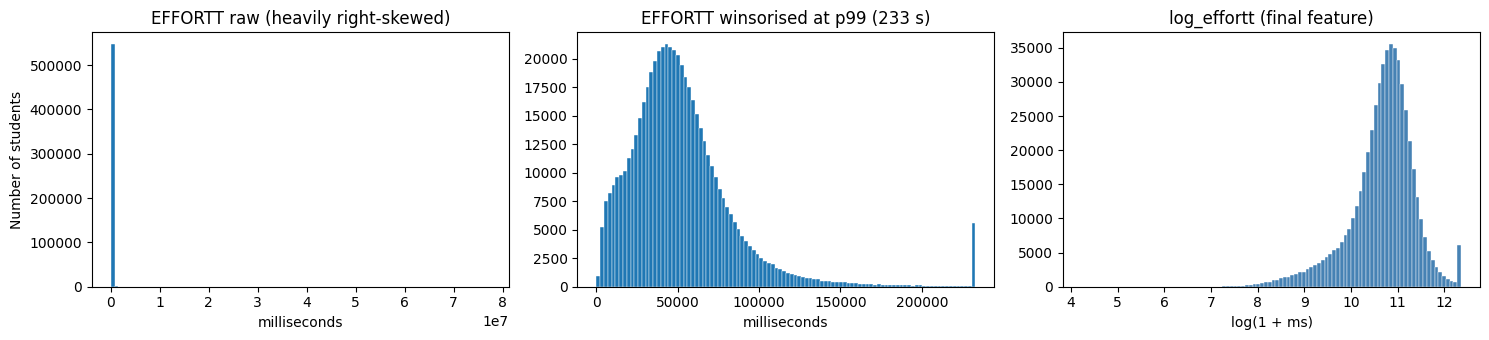


Diagnostic plot saved: /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/nb02_diagnostics/effortt_transformation.png


In [125]:
# EFFORTT processing: diagnostic, Tier-3 outlier treatment, log transform
#
# EFFORTT is the total response time (in milliseconds) on the effort-thermometer
# questionnaire block. It serves as a self-reported effort proxy aligned with
# Self-Regulated Learning theory (Zimmerman, 2000) and rapid-guessing research
# (Wise & Kong, 2005). Distribution is heavily right-skewed and log-normal.
#
# Treatment strategy:
#   1. Winsorize at 99th percentile (upper tail only). Rationale: lower-tail
#      values represent substantive low-engagement signals that should be
#      preserved; upper-tail extreme values (max ~21 hours) are system
#      artifacts.
#   2. Log1p transform to normalise the distribution for ML modelling.

print("EFFORTT diagnostic (pre-treatment)")
print(df["EFFORTT"].describe(percentiles=[0.01, 0.25, 0.5, 0.75, 0.95, 0.99, 0.999]).round(1))
print(f"  Missing: {df['EFFORTT'].isna().sum():,} "
      f"({100*df['EFFORTT'].isna().mean():.2f}%)")

# Determine winsorisation threshold
p99_effortt = df["EFFORTT"].quantile(0.99)
n_to_cap = int((df["EFFORTT"] > p99_effortt).sum())

print(f"\nWinsorisation threshold (p99): {p99_effortt:,.0f} ms "
      f"({p99_effortt/60000:.2f} min)")
print(f"  Values to cap: {n_to_cap:,} "
      f"({100*n_to_cap/df['EFFORTT'].notna().sum():.2f} percent of non-null)")

# Apply: winsorize upper tail only
df["EFFORTT_winsorized"] = df["EFFORTT"].clip(upper=p99_effortt)

# Log1p transform (safe for small values, normalises distribution)
df["log_effortt"] = np.log1p(df["EFFORTT_winsorized"]).astype("float32")

print("\nEFFORTT after winsorisation (ms):")
print(df["EFFORTT_winsorized"].describe().round(1))

print("\nlog_effortt (final feature) distribution:")
print(df["log_effortt"].describe().round(3))

# Diagnostic plot
fig, axes = plt.subplots(1, 3, figsize=(15, 3.5))

axes[0].hist(df["EFFORTT"].dropna(), bins=100, edgecolor="white", linewidth=0.3)
axes[0].set_title("EFFORTT raw (heavily right-skewed)")
axes[0].set_xlabel("milliseconds")
axes[0].set_ylabel("Number of students")

axes[1].hist(df["EFFORTT_winsorized"].dropna(), bins=100, edgecolor="white", linewidth=0.3)
axes[1].set_title(f"EFFORTT winsorised at p99 ({p99_effortt/1000:.0f} s)")
axes[1].set_xlabel("milliseconds")

axes[2].hist(df["log_effortt"].dropna(), bins=100, edgecolor="white", linewidth=0.3,
             color="steelblue")
axes[2].set_title("log_effortt (final feature)")
axes[2].set_xlabel("log(1 + ms)")

plt.tight_layout()

# Save diagnostic plot
effortt_fig_path = NB02_DIAG_DIR / "effortt_transformation.png"
fig.savefig(effortt_fig_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()
print(f"\nDiagnostic plot saved: {effortt_fig_path}")

In [126]:
# Item-level standardisation of log response times
#
# Rationale (editorial methodological requirement, addressed in this cell):
#   PISA 2022 uses a hybrid Multi-Stage Adaptive Testing (MSAT) design. Each
#   student is administered a different testlet sequence based on partial
#   performance and random routing, leading to systematic variation in which
#   items a student sees. Additionally, empirical NB01 diagnostics demonstrated
#   that CM (trend) and CMA (new 2022) items differ in median response-time
#   scale (CMA median RT / CM median RT = 0.90).
#
#   If behavioural features are aggregated from raw response times without
#   accounting for item-level differences, students exposed to systematically
#   slower (or faster) item sets will appear to have different behavioural
#   tendencies that actually reflect item exposure rather than genuine
#   student-level processing styles (De Boeck & Scalise, 2019; Goldhammer
#   et al., 2014).
#
#   To address this, we compute item-level standardised log response times:
#     z_log_RT(s, i) = (log_RT(s, i) - mean_i(log_RT)) / sd_i(log_RT)
#
#   where the mean and SD for item i are computed across all students who
#   attempted that item (using the full adaptive_sample to maximise
#   standardisation precision). This yields z-scores that compare each
#   student's speed relative to peers on the same item, removing item-level
#   exposure and difficulty confounding.
#
#   Features downstream are computed TWICE: once on raw log(TT) (suffix _raw)
#   and once on standardised z-scores (primary feature, no suffix). The raw
#   versions serve as sensitivity analysis benchmarks in NB03.

print("Computing per-item log(TT) mean and standard deviation")
print("Method: compute over all non-null, non-zero TT observations per item")
print(f"Number of items to standardise: {len(all_tt_cols)}")

# Per-item log(TT) distribution statistics
# We operate directly on log-transformed TT because RT is log-normal, so
# standardisation in log space is the principled choice
item_log_tt_mean = {}
item_log_tt_std = {}
item_valid_n = {}

start = time.time()
for col in all_tt_cols:
    # Get valid observations (non-null, positive)
    vals = df[col].dropna()
    vals = vals[vals > 0]
    
    if len(vals) < 2:
        # Cannot compute std with fewer than 2 observations
        item_log_tt_mean[col] = np.nan
        item_log_tt_std[col] = np.nan
        item_valid_n[col] = len(vals)
        continue
    
    log_vals = np.log(vals.values)
    item_log_tt_mean[col] = log_vals.mean()
    item_log_tt_std[col] = log_vals.std(ddof=1)
    item_valid_n[col] = len(vals)

elapsed = time.time() - start
print(f"Item-level stats computed in {elapsed:.1f}s")

# Summary diagnostics
mean_series = pd.Series(item_log_tt_mean)
std_series = pd.Series(item_log_tt_std)
n_series = pd.Series(item_valid_n)

print(f"\nPer-item log(TT) mean distribution:")
print(f"Min   : {mean_series.min():.3f}")
print(f"Median: {mean_series.median():.3f}")
print(f"Max   : {mean_series.max():.3f}")
print(f"Range of exp(mean) in seconds: "
      f"{np.exp(mean_series.min())/1000:.1f} - {np.exp(mean_series.max())/1000:.1f} s")

print(f"\nPer-item log(TT) standard deviation distribution:")
print(f"Min   : {std_series.min():.3f}")
print(f"Median: {std_series.median():.3f}")
print(f"Max   : {std_series.max():.3f}")

print(f"\nItems with insufficient observations (<2): "
      f"{(n_series < 2).sum()}")
print(f"Items with std == 0 (degenerate, cannot standardise): "
      f"{(std_series == 0).sum()}")

# Compare CM vs CMA item-level log means (empirical confirmation of MSAT
# confounding that standardisation removes)
cm_means = [item_log_tt_mean[c] for c in cm_tt_cols if not np.isnan(item_log_tt_mean[c])]
cma_means = [item_log_tt_mean[c] for c in cma_tt_cols if not np.isnan(item_log_tt_mean[c])]

print(f"\nCM vs CMA item-level log(TT) means:")
print(f"CM (n={len(cm_means)}): median log-mean = {np.median(cm_means):.3f} "
      f"(exp = {np.exp(np.median(cm_means))/1000:.1f} s)")
print(f"CMA (n={len(cma_means)}): median log-mean = {np.median(cma_means):.3f} "
      f"(exp = {np.exp(np.median(cma_means))/1000:.1f} s)")
print(f"Difference: {np.median(cm_means) - np.median(cma_means):.3f} log-units")
print(f"This systematic difference is what standardisation will eliminate")

# Save item-level stats to the nb02 diagnostics folder for thesis reference
item_stats_df = pd.DataFrame({
    "item": list(item_log_tt_mean.keys()),
    "log_tt_mean": list(item_log_tt_mean.values()),
    "log_tt_std": list(item_log_tt_std.values()),
    "n_valid": list(item_valid_n.values()),
})
item_stats_df["family"] = item_stats_df["item"].apply(
    lambda c: "CM" if not c.startswith("CMA") else "CMA"
)
item_stats_df["mean_tt_seconds"] = np.exp(item_stats_df["log_tt_mean"]) / 1000

stats_path = NB02_DIAG_DIR / "item_level_standardisation_stats.csv"
item_stats_df.to_csv(stats_path, index=False)
print(f"\nItem-level stats saved: {stats_path}")

print_memory()

Computing per-item log(TT) mean and standard deviation
Method: compute over all non-null, non-zero TT observations per item
Number of items to standardise: 234
Item-level stats computed in 0.9s

Per-item log(TT) mean distribution:
Min   : 10.049
Median: 11.010
Max   : 11.897
Range of exp(mean) in seconds: 23.1 - 146.8 s

Per-item log(TT) standard deviation distribution:
Min   : 0.607
Median: 0.972
Max   : 1.754

Items with insufficient observations (<2): 0
Items with std == 0 (degenerate, cannot standardise): 0

CM vs CMA item-level log(TT) means:
CM (n=74): median log-mean = 11.086 (exp = 65.2 s)
CMA (n=160): median log-mean = 10.893 (exp = 53.8 s)
Difference: 0.193 log-units
This systematic difference is what standardisation will eliminate

Item-level stats saved: /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/nb02_diagnostics/item_level_standardisation_stats.csv
Current process memory: 1.33 GB | System RAM available: 5.45 GB


In [127]:
# Build two response-time matrices for downstream feature engineering
#
# log_tt_raw_matrix: log-transformed raw TT values (features computed on this
#                    will get "_raw" suffix, serving as sensitivity benchmarks)
# log_tt_std_matrix: item-standardised z-scores (primary feature space)
#
# Memory strategy: both matrices are float32 to keep footprint manageable.
# Matrix shape: (554,680 students, 234 items) -> ~0.52 GB per matrix in float32.
# We build them once here and reuse throughout the notebook.

print("Building raw and standardised log(TT) matrices")

n_students = len(df)
n_items = len(all_tt_cols)
print(f"Matrix shape: {n_students:,} students x {n_items} items")

# Extract raw TT matrix (milliseconds)
print("Extracting TT matrix from DataFrame...")
start = time.time()
tt_matrix = df[all_tt_cols].values.astype(np.float32)
# Treat zeros as NaN (zero TT means item not seen or technical artefact)
tt_matrix[tt_matrix <= 0] = np.nan
print(f"Extracted in {time.time()-start:.1f}s")

# Build raw log(TT) matrix
print("Building log_tt_raw_matrix (log of raw TT)...")
start = time.time()
with np.errstate(invalid="ignore", divide="ignore"):
    log_tt_raw_matrix = np.log(tt_matrix).astype(np.float32)
print(f"Built in {time.time()-start:.1f}s")

# Build standardised matrix
# For each item (column), subtract item mean and divide by item std
print("Building log_tt_std_matrix (item-level z-scores)...")
start = time.time()

# Vectorised approach: create two arrays aligned with columns
col_means = np.array([item_log_tt_mean[c] for c in all_tt_cols], dtype=np.float32)
col_stds = np.array([item_log_tt_std[c] for c in all_tt_cols], dtype=np.float32)

# Guard against zero std (degenerate items)
col_stds_safe = np.where(col_stds > 0, col_stds, 1.0)

# Broadcasting: (students, items) - (items,) / (items,)
log_tt_std_matrix = ((log_tt_raw_matrix - col_means) / col_stds_safe).astype(np.float32)

# Set standardised values to NaN where original was NaN or where item had zero std
log_tt_std_matrix[np.isnan(log_tt_raw_matrix)] = np.nan
degenerate_cols_mask = (col_stds == 0)
if degenerate_cols_mask.any():
    log_tt_std_matrix[:, degenerate_cols_mask] = np.nan
    print(f"Note: {degenerate_cols_mask.sum()} columns had zero std and "
          f"were set to NaN in standardised matrix")

print(f"Built in {time.time()-start:.1f}s")

# Free the raw tt_matrix (we keep log versions only)
del tt_matrix
gc.collect()

# Report matrix sizes
raw_mem_gb = log_tt_raw_matrix.nbytes / 1e9
std_mem_gb = log_tt_std_matrix.nbytes / 1e9
print(f"\nMemory footprint:")
print(f"log_tt_raw_matrix : {raw_mem_gb:.2f} GB")
print(f"log_tt_std_matrix : {std_mem_gb:.2f} GB")

print_memory()

Building raw and standardised log(TT) matrices
Matrix shape: 554,680 students x 234 items
Extracting TT matrix from DataFrame...
Extracted in 0.2s
Building log_tt_raw_matrix (log of raw TT)...
Built in 0.7s
Building log_tt_std_matrix (item-level z-scores)...
Built in 0.7s

Memory footprint:
log_tt_raw_matrix : 0.52 GB
log_tt_std_matrix : 0.52 GB
Current process memory: 2.41 GB | System RAM available: 4.74 GB


Sanity checks on standardised log(TT) matrix
Per-item mean of standardised values (should be approximately 0):
Min: -0.000002
Max: +0.000002
Mean of absolute values: 0.000000

Per-item SD of standardised values (should be approximately 1):
Min   : 1.000000
Max   : 1.000000
Median: 1.000000

CM vs CMA after standardisation (per-item means):
CM items : median = +0.000000
CMA items: median = -0.000000
Difference: +0.000000
This should be near zero — standardisation removes cross-family
systematic RT differences while preserving within-student variation


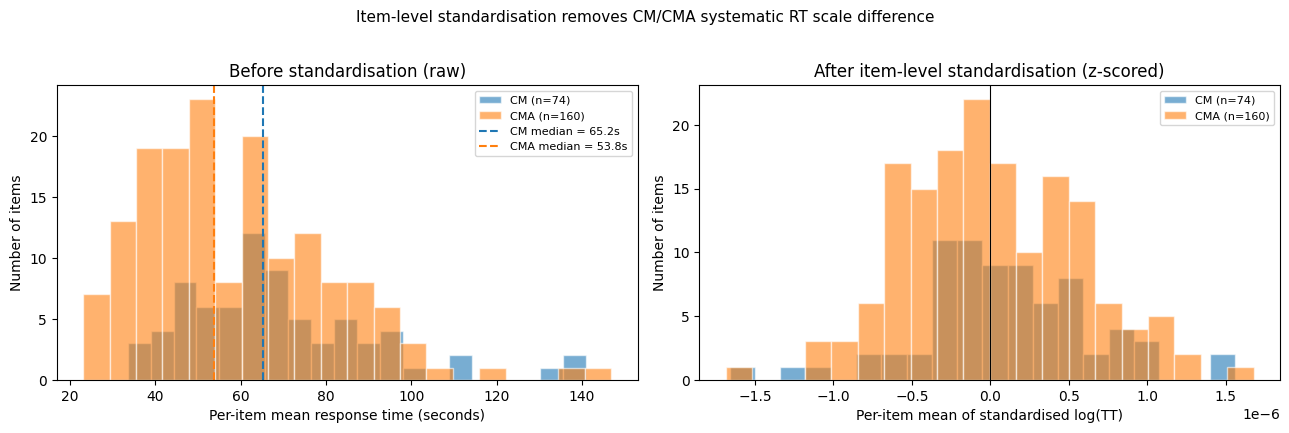


  Validation plot saved: /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/nb02_diagnostics/standardisation_validation.png
Caption saved: /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/nb02_diagnostics/standardisation_validation_caption.md
Current process memory: 2.54 GB | System RAM available: 4.74 GB


In [128]:
# Sanity checks on the standardised matrix
#
# Validation criteria:
#   1. Per-item mean of standardised values should be approximately 0
#   2. Per-item SD of standardised values should be approximately 1
#   3. The CM-CMA systematic difference visible in raw log(TT) should be
#      eliminated in the standardised version

print("Sanity checks on standardised log(TT) matrix")

# Per-item mean and std of standardised matrix (ignore NaN)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    col_means_std = np.nanmean(log_tt_std_matrix, axis=0)
    col_stds_std = np.nanstd(log_tt_std_matrix, axis=0, ddof=1)

print(f"Per-item mean of standardised values (should be approximately 0):")
print(f"Min: {np.nanmin(col_means_std):+.6f}")
print(f"Max: {np.nanmax(col_means_std):+.6f}")
print(f"Mean of absolute values: {np.nanmean(np.abs(col_means_std)):.6f}")

print(f"\nPer-item SD of standardised values (should be approximately 1):")
print(f"Min   : {np.nanmin(col_stds_std):.6f}")
print(f"Max   : {np.nanmax(col_stds_std):.6f}")
print(f"Median: {np.nanmedian(col_stds_std):.6f}")

# Validate: CM vs CMA in standardised space should no longer systematically differ
# Compute per-item mean of standardised values for CM and CMA families
cm_idx = [i for i, c in enumerate(all_tt_cols) if not c.startswith("CMA")]
cma_idx = [i for i, c in enumerate(all_tt_cols) if c.startswith("CMA")]

cm_std_means = col_means_std[cm_idx]
cma_std_means = col_means_std[cma_idx]

print(f"\nCM vs CMA after standardisation (per-item means):")
print(f"CM items : median = {np.nanmedian(cm_std_means):+.6f}")
print(f"CMA items: median = {np.nanmedian(cma_std_means):+.6f}")
print(f"Difference: {np.nanmedian(cm_std_means) - np.nanmedian(cma_std_means):+.6f}")
print(f"This should be near zero — standardisation removes cross-family")
print(f"systematic RT differences while preserving within-student variation")

# Visual validation: raw vs standardised distributions
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

# Left: raw log(TT) distributions for CM and CMA (per-item medians)
cm_raw_medians = [np.exp(item_log_tt_mean[c]) / 1000 
                  for c in cm_tt_cols 
                  if not np.isnan(item_log_tt_mean[c])]
cma_raw_medians = [np.exp(item_log_tt_mean[c]) / 1000 
                   for c in cma_tt_cols 
                   if not np.isnan(item_log_tt_mean[c])]

axes[0].hist(cm_raw_medians, bins=20, alpha=0.6, color="#1f77b4",
             label=f"CM (n={len(cm_raw_medians)})", edgecolor="white")
axes[0].hist(cma_raw_medians, bins=20, alpha=0.6, color="#ff7f0e",
             label=f"CMA (n={len(cma_raw_medians)})", edgecolor="white")
axes[0].axvline(np.median(cm_raw_medians), color="#1f77b4", linestyle="--",
                label=f"CM median = {np.median(cm_raw_medians):.1f}s")
axes[0].axvline(np.median(cma_raw_medians), color="#ff7f0e", linestyle="--",
                label=f"CMA median = {np.median(cma_raw_medians):.1f}s")
axes[0].set_xlabel("Per-item mean response time (seconds)")
axes[0].set_ylabel("Number of items")
axes[0].set_title("Before standardisation (raw)")
axes[0].legend(loc="upper right", fontsize=8)

# Right: standardised per-item means should cluster near zero for both families
axes[1].hist(cm_std_means, bins=20, alpha=0.6, color="#1f77b4",
             label=f"CM (n={len(cm_std_means)})", edgecolor="white")
axes[1].hist(cma_std_means, bins=20, alpha=0.6, color="#ff7f0e",
             label=f"CMA (n={len(cma_std_means)})", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="-", linewidth=0.8)
axes[1].set_xlabel("Per-item mean of standardised log(TT)")
axes[1].set_ylabel("Number of items")
axes[1].set_title("After item-level standardisation (z-scored)")
axes[1].legend(loc="upper right", fontsize=8)

fig.suptitle(
    "Item-level standardisation removes CM/CMA systematic RT scale difference",
    fontsize=11, y=1.02
)
plt.tight_layout()

std_fig_path = NB02_DIAG_DIR / "standardisation_validation.png"
fig.savefig(std_fig_path, dpi=150, bbox_inches="tight", facecolor="white")
plt.show()

print(f"\n  Validation plot saved: {std_fig_path}")

# Save a thesis-ready caption for this figure
caption = f"""
Figure X caption (thesis-ready):

Empirical validation of item-level standardisation. Left panel: before
standardisation, per-item mean response times differ systematically between
CM (trend) and CMA (new 2022) items (CM median = {np.median(cm_raw_medians):.1f}s,
CMA median = {np.median(cma_raw_medians):.1f}s), reflecting the heterogeneous
scale produced by PISA 2022's hybrid MSAT design. Right panel: after
item-level z-scoring of log response times, per-item means cluster near
zero for both families (CM median = {np.nanmedian(cm_std_means):+.3f},
CMA median = {np.nanmedian(cma_std_means):+.3f}), confirming that the
standardisation procedure removes cross-family systematic scale differences
while preserving within-student response-time variation for behavioural
feature construction.
"""
(NB02_DIAG_DIR / "standardisation_validation_caption.md").write_text(caption)
print(f"Caption saved: {NB02_DIAG_DIR / 'standardisation_validation_caption.md'}")

print_memory()

In [129]:
# Time-based behavioural features — dual tracking
#
# This notebook produces TWO versions of each time-based feature:
# - Primary: computed on item-standardised log response times (z-scored
#   per item across all students in the adaptive sample). This removes
#   MSAT item exposure and CM/CMA item-family confounding documented in
#   NB01 diagnostics.
# - Sensitivity (_raw suffix): computed on raw log response times.
#   Replicates operationalisations in prior PISA process-data literature.
#
# Feature interpretations (used throughout thesis):
#
# log_total_time
# Raw log of total seconds spent on all items. No standardisation applies
# because summation requires a consistent duration scale. Higher values
# indicate greater overall engagement.
#
# log_mean_time_per_item (primary, standardised)
# Mean of item-standardised log(TT). Values near 0 indicate a student
# whose average speed position matches the peer average. Positive values
# indicate a systematically slower-than-peers profile; negative values
# indicate a systematically faster-than-peers profile. This is the
# MSAT-corrected analogue of raw speed.
#
# log_mean_time_per_item_raw (sensitivity)
# Mean of raw log(TT) in milliseconds. Higher values indicate longer
# absolute time per item, but this metric is confounded by which items
# the student saw. Retained for comparison with prior literature.
#
# time_cv (primary)
# Standard deviation of item-standardised log(TT) per student. This is
# NOT a coefficient of variation in the traditional sense; we retain the
# name for thesis-vocabulary continuity but the construct is:
#
# "How variable is the student's peer-relative speed position across items?"
#
# Low values (e.g., 0.3) indicate a student whose relative speed
# position is consistent across items (e.g., always at approximately
# the same z-score). High values (e.g., 1.5) indicate a student whose
# relative position varies substantially from item to item, which is
# hypothesised to reflect metacognitive monitoring and difficulty-
# sensitive time allocation (System 2 engagement in Dual-Process Theory).
# Expected range: roughly 0.3 to 2.0 in realistic student populations.
#
# time_cv_raw (sensitivity)
# Traditional coefficient of variation = SD / mean of raw log(TT).
# Scale-independent measure of absolute speed variability, but confounded
# by item exposure. Retained for comparison with prior literature.

print("Computing time-based behavioural features (dual tracking)")

# Feature 1: log_total_time
# No standardisation applies: summation of z-scores is not meaningful.
# This feature uses raw TT values aggregated to total seconds.
print("Computing log_total_time (raw TT sum, log-transformed)...")

# Reconstruct raw TT matrix from log_tt_raw_matrix (already in memory)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    raw_tt_matrix = np.exp(log_tt_raw_matrix).astype(np.float32)

total_time_raw = np.nansum(raw_tt_matrix, axis=1)
df["log_total_time"] = np.log1p(total_time_raw).astype(np.float32)

del raw_tt_matrix
gc.collect()

# Feature 2: log_mean_time_per_item (primary = standardised; sensitivity = raw)
print("Computing log_mean_time_per_item (primary, standardised)...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    mean_log_std = np.nanmean(log_tt_std_matrix, axis=1)
df["log_mean_time_per_item"] = mean_log_std.astype(np.float32)

print("Computing log_mean_time_per_item_raw (sensitivity, raw)...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    mean_log_raw = np.nanmean(log_tt_raw_matrix, axis=1)
df["log_mean_time_per_item_raw"] = mean_log_raw.astype(np.float32)

# Feature 3: time_cv (primary = SD of z-scored log(TT); sensitivity = traditional CV)
print("Computing time_cv (primary, SD of standardised log(TT) per student)...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    std_log_std = np.nanstd(log_tt_std_matrix, axis=1, ddof=1)
df["time_cv"] = std_log_std.astype(np.float32)

print("Computing time_cv_raw (sensitivity, traditional CV on raw log(TT))...")
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    std_log_raw = np.nanstd(log_tt_raw_matrix, axis=1, ddof=1)
    time_cv_raw = std_log_raw / mean_log_raw
df["time_cv_raw"] = time_cv_raw.astype(np.float32)

# Distribution summary
print("\nTime-based feature distributions:")
time_features = ["log_total_time",
                 "log_mean_time_per_item", "log_mean_time_per_item_raw",
                 "time_cv", "time_cv_raw"]
print(df[time_features].describe().round(3))

# Primary feature interpretation anchors
print("\nInterpretation anchors for thesis reporting:")

print("\nlog_mean_time_per_item (primary, standardised):")
print("Theoretical zero anchor: a student matching peer-average speed on")
print("every item they saw. Positive values = slower than peers; negative")
print("values = faster than peers.")
print(f"Sample mean  : {df['log_mean_time_per_item'].mean():+.3f}")
print(f"Sample median: {df['log_mean_time_per_item'].median():+.3f}")
print(f"Sample SD    : {df['log_mean_time_per_item'].std():.3f}")

print("\ntime_cv (primary, SD of z-scored log(TT)):")
print("NOT a traditional CV. Measures within-student variability in")
print("peer-relative speed position across items. Low values indicate")
print("consistent relative position (either steady fast or steady slow);")
print("high values indicate position changes across items (hypothesised")
print("to reflect metacognitive monitoring / System 2 engagement).")
print(f"Sample mean  : {df['time_cv'].mean():.3f}")
print(f"Sample median: {df['time_cv'].median():.3f}")
print(f"Sample P5-P95: {df['time_cv'].quantile(0.05):.3f} - "
      f"{df['time_cv'].quantile(0.95):.3f}")

# Raw vs standardised diagnostic: how much does standardisation change things?
print("\nRaw-vs-standardised correlations (Pearson):")
print(f"log_mean_time_per_item: "
      f"r = {df[['log_mean_time_per_item', 'log_mean_time_per_item_raw']].corr().iloc[0,1]:.3f}")
print(f"time_cv               : "
      f"r = {df[['time_cv', 'time_cv_raw']].corr().iloc[0,1]:.3f}")
print("(High correlations indicate standardisation preserves relative")
print("ranking while removing systematic item-exposure bias.)")

print_memory()

Computing time-based behavioural features (dual tracking)
Computing log_total_time (raw TT sum, log-transformed)...
Computing log_mean_time_per_item (primary, standardised)...
Computing log_mean_time_per_item_raw (sensitivity, raw)...
Computing time_cv (primary, SD of standardised log(TT) per student)...
Computing time_cv_raw (sensitivity, traditional CV on raw log(TT))...

Time-based feature distributions:
       log_total_time  log_mean_time_per_item  log_mean_time_per_item_raw     time_cv  time_cv_raw
count      554680.000              554680.000                  554680.000  554680.000   554680.000
mean           14.675                   0.019                      10.975       0.768        0.079
std             0.460                   0.570                       0.595       0.339        0.035
min            10.036                  -4.838                       6.329       0.137        0.016
25%            14.529                  -0.176                      10.758       0.540        0

In [130]:
# Effort regulation: linear regression slope of log(TT) on item presentation order
#
# Theoretical role (Zimmerman, 2000; SRL framework):
#   Captures within-student trajectory of time allocation across the test:
#   - Negative slope: declining time allocation (fatigue, motivation decline)
#   - Positive slope: increasing time allocation (warm-up, engagement growth)
#   - Near-zero slope: stable time allocation
#
# Computed in both feature spaces for sensitivity analysis:
#   effort_regulation     : slope on item-standardised log(TT) — PRIMARY
#                           Interpretation: change in relative speed position
#                           across items. Controls for item-level RT scale.
#   effort_regulation_raw : slope on raw log(TT) — SENSITIVITY
#                           Traditional operationalisation in prior literature.
#
# Operational note on item ordering:
#   Column order in the parquet file reflects the order in which items appear
#   across all test booklets combined. This is not identical to the exact
#   presentation order each individual student experienced under MSAT, but
#   captures enough of the sequential signal to detect fatigue trends at the
#   population level. A limitation to document in the thesis.

print("Computing effort_regulation (dual tracking)")

n_students_now = len(df)
n_items_now = len(all_tt_cols)

# Common denominator: item order indices (0, 1, 2, ..., 233)
item_order = np.arange(n_items_now, dtype=np.float64)

def compute_slopes_per_row(matrix, feature_name):
    """Compute per-row linear regression slope of matrix values on item_order,
    skipping NaN values."""
    slopes = np.full(n_students_now, np.nan, dtype=np.float32)
    
    print(f"Processing {feature_name}...")
    start = time.time()
    
    # Process in chunks for progress feedback and memory headroom
    chunk_size = 50000
    for chunk_start in range(0, n_students_now, chunk_size):
        chunk_end = min(chunk_start + chunk_size, n_students_now)
        chunk = matrix[chunk_start:chunk_end]
        
        for i in range(chunk.shape[0]):
            row = chunk[i]
            valid = ~np.isnan(row)
            if valid.sum() < 10:
                continue
            x = item_order[valid]
            y = row[valid]
            x_mean = x.mean()
            y_mean = y.mean()
            x_var = ((x - x_mean) ** 2).sum()
            if x_var == 0:
                continue
            slope = ((x - x_mean) * (y - y_mean)).sum() / x_var
            slopes[chunk_start + i] = slope
        
        if (chunk_end - chunk_start) == chunk_size or chunk_end == n_students_now:
            elapsed = time.time() - start
            pct = 100 * chunk_end / n_students_now
            print(f"    {chunk_end:,}/{n_students_now:,} "
                  f"({pct:.0f}% in {elapsed:.0f}s)")
    
    return slopes

# Primary: slopes on standardised log(TT)
df["effort_regulation"] = compute_slopes_per_row(
    log_tt_std_matrix, "effort_regulation (standardised, primary)"
)

# Sensitivity: slopes on raw log(TT)
df["effort_regulation_raw"] = compute_slopes_per_row(
    log_tt_raw_matrix, "effort_regulation_raw (raw log(TT), sensitivity)"
)

# Distribution comparison
print("\n  Distribution comparison:")
print(df[["effort_regulation", "effort_regulation_raw"]].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]
).round(5))

# Interpretive stats
print("\nEffort regulation interpretation (primary, standardised):")
n_neg_std = (df["effort_regulation"] < 0).sum()
n_pos_std = (df["effort_regulation"] > 0).sum()
print(f"    Negative slope (declining): {n_neg_std:,} "
      f"({100*n_neg_std/len(df):.1f} percent)")
print(f"  Positive slope (rising)   : {n_pos_std:,} "
      f"({100*n_pos_std/len(df):.1f} percent)")

print("\nEffort regulation interpretation (raw, sensitivity):")
n_neg_raw = (df["effort_regulation_raw"] < 0).sum()
n_pos_raw = (df["effort_regulation_raw"] > 0).sum()
print(f"Negative slope (declining): {n_neg_raw:,} "
      f"({100*n_neg_raw/len(df):.1f} percent)")
print(f"Positive slope (rising)   : {n_pos_raw:,} "
      f"({100*n_pos_raw/len(df):.1f} percent)")

# Agreement between raw and standardised
print(f"\nRaw-vs-standardised correlation: "
      f"r = {df[['effort_regulation', 'effort_regulation_raw']].corr().iloc[0,1]:.3f}")

# Sign agreement (both methods call student fatigued/engaged?)
signs_agree = ((df["effort_regulation"] < 0) == (df["effort_regulation_raw"] < 0))
print(f"Sign agreement between versions: {signs_agree.mean()*100:.1f} percent")

print_memory()

Computing effort_regulation (dual tracking)
Processing effort_regulation (standardised, primary)...
    50,000/554,680 (9% in 1s)
    100,000/554,680 (18% in 1s)
    150,000/554,680 (27% in 2s)
    200,000/554,680 (36% in 3s)
    250,000/554,680 (45% in 3s)
    300,000/554,680 (54% in 4s)
    350,000/554,680 (63% in 5s)
    400,000/554,680 (72% in 5s)
    450,000/554,680 (81% in 6s)
    500,000/554,680 (90% in 7s)
    550,000/554,680 (99% in 7s)
    554,680/554,680 (100% in 7s)
Processing effort_regulation_raw (raw log(TT), sensitivity)...
    50,000/554,680 (9% in 1s)
    100,000/554,680 (18% in 1s)
    150,000/554,680 (27% in 2s)
    200,000/554,680 (36% in 3s)
    250,000/554,680 (45% in 3s)
    300,000/554,680 (54% in 4s)
    350,000/554,680 (63% in 5s)
    400,000/554,680 (72% in 5s)
    450,000/554,680 (81% in 6s)
    500,000/554,680 (90% in 7s)
    550,000/554,680 (99% in 7s)
    554,680/554,680 (100% in 7s)

  Distribution comparison:
       effort_regulation  effort_regulation

In [131]:
# Visit, action, and first-visit behavioural features
#
# These features do not require item-level standardisation because they are
# count-based (visits, actions) or ratio-based (first-visit completion) rather
# than time-based. They are derived directly from the raw process columns.
#
# Features:
#   mean_visits_per_item          : continuous visit intensity
#   revisit_ratio                 : proportion of items visited > 1 times
#   mean_actions_per_item         : raw mean, Tier-2 winsorised below
#   log_mean_actions              : log-transformed (primary, for ML)
#   first_visit_completion_ratio  : F/TT per item, averaged across items

print("Computing visit, action, and first-visit features")

# Extract matrices (float32 for memory)
v_matrix = df[all_v_cols].values.astype(np.float32)
a_matrix = df[all_a_cols].values.astype(np.float32)
f_matrix = df[all_f_cols].values.astype(np.float32)

# Clean: 0 and NaN both indicate "no engagement with item"
v_clean = np.where((v_matrix > 0) & ~np.isnan(v_matrix), v_matrix, np.nan)
a_clean = np.where((a_matrix > 0) & ~np.isnan(a_matrix), a_matrix, np.nan)
f_clean = np.where((f_matrix > 0) & ~np.isnan(f_matrix), f_matrix, np.nan)

# 1. Mean visits per item
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    df["mean_visits_per_item"] = np.nanmean(v_clean, axis=1).astype(np.float32)

# 2. Revisit ratio: proportion of items visited more than once
revisit_counts = np.nansum((v_clean > 1).astype(np.float32), axis=1)
df["revisit_ratio"] = (revisit_counts / df["n_items_valid"].values).astype(np.float32)

# 3. Mean actions per item (raw; will be Tier-2 winsorised next cell)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    df["mean_actions_per_item"] = np.nanmean(a_clean, axis=1).astype(np.float32)

# 4. First-visit completion ratio
# Reconstruct raw TT for division (from log_tt_raw_matrix)
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    tt_for_fvt = np.exp(log_tt_raw_matrix).astype(np.float32)

with np.errstate(divide="ignore", invalid="ignore"):
    fvt_ratio_matrix = f_clean / tt_for_fvt
# Clip to [0, 1]: F should not exceed TT; values > 1 are data artefacts
fvt_ratio_matrix = np.clip(fvt_ratio_matrix, 0, 1)

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)
    df["first_visit_completion_ratio"] = np.nanmean(
        fvt_ratio_matrix, axis=1
    ).astype(np.float32)

# Memory cleanup
del v_matrix, a_matrix, f_matrix
del v_clean, a_clean, f_clean
del fvt_ratio_matrix, tt_for_fvt
gc.collect()

# Summary
print("\n  Visit, action, and first-visit feature summary:")
print(df[["mean_visits_per_item", "revisit_ratio",
         "mean_actions_per_item", "first_visit_completion_ratio"]].describe().round(3))

print_memory()

Computing visit, action, and first-visit features

  Visit, action, and first-visit feature summary:
       mean_visits_per_item  revisit_ratio  mean_actions_per_item  first_visit_completion_ratio
count            554680.000     554680.000             554654.000                    554654.000
mean                  1.139          0.095                 17.049                         0.514
std                   0.203          0.109                 13.452                         0.124
min                   1.000          0.000                  1.000                         0.000
25%                   1.000          0.000                  9.000                         0.436
50%                   1.067          0.067                 14.345                         0.522
75%                   1.200          0.138                 21.964                         0.602
max                   8.091          1.000               2338.104                         0.959
Current process memory: 0.98 GB | S

In [132]:
# Tier 2 outlier treatment: mean_actions_per_item winsorisation
#
# Rationale (Greiff, Wustenberg & Avvisati, 2015):
#   Extreme action counts (observed maximum = 2,338 actions per item) reflect
#   interface exploration, automated clicking, or technical artefacts rather
#   than substantive problem-solving behaviour. We apply p99 winsorisation
#   (not removal) to preserve the behavioural signal of high-interaction
#   students while capping leverage from data-quality anomalies.
#
# Post-winsorisation, we apply log1p transformation to normalise the
# right-skewed distribution for ML modelling. The log-transformed version
# (log_mean_actions) is the primary feature; raw mean_actions_per_item is
# retained for sensitivity analysis reference.

print("Tier 2 outlier treatment: mean_actions_per_item winsorisation")

print("\nPre-winsorisation diagnostic:")
print(df["mean_actions_per_item"].describe(
    percentiles=[0.5, 0.75, 0.95, 0.99, 0.999]
).round(2))

# Compute winsorisation threshold
p99_actions = df["mean_actions_per_item"].quantile(0.99)
p999_actions = df["mean_actions_per_item"].quantile(0.999)
n_above_p99 = int((df["mean_actions_per_item"] > p99_actions).sum())
n_above_p999 = int((df["mean_actions_per_item"] > p999_actions).sum())

print(f"\n99.0th percentile: {p99_actions:.2f}")
print(f"99.9th percentile: {p999_actions:.2f}")
print(f"Maximum observed : {df['mean_actions_per_item'].max():.2f}")
print(f"\nValues to cap at p99 : {n_above_p99:,} "
      f"({100*n_above_p99/df['mean_actions_per_item'].notna().sum():.2f} percent of non-null)")
print(f"Values above p999: {n_above_p999:,} (retained, not capped)")

# Apply winsorisation at p99 (upper tail only)
df["mean_actions_per_item"] = df["mean_actions_per_item"].clip(upper=p99_actions)

# Log1p transform for ML (primary feature)
df["log_mean_actions"] = np.log1p(df["mean_actions_per_item"]).astype(np.float32)

print("\nPost-winsorisation mean_actions_per_item:")
print(df["mean_actions_per_item"].describe().round(2))

print("\nlog_mean_actions (primary feature) distribution:")
print(df["log_mean_actions"].describe().round(3))

print_memory()

Tier 2 outlier treatment: mean_actions_per_item winsorisation

Pre-winsorisation diagnostic:
count    554654.00
mean         17.05
std          13.45
min           1.00
50%          14.34
75%          21.96
95%          38.13
99%          56.13
99.9%        99.91
max        2338.10
Name: mean_actions_per_item, dtype: float64

99.0th percentile: 56.13
99.9th percentile: 99.91
Maximum observed : 2338.10

Values to cap at p99 : 5,545 (1.00 percent of non-null)
Values above p999: 555 (retained, not capped)

Post-winsorisation mean_actions_per_item:
count    554654.00
mean         16.82
std          10.67
min           1.00
25%           9.00
50%          14.34
75%          21.96
max          56.13
Name: mean_actions_per_item, dtype: float64

log_mean_actions (primary feature) distribution:
count    554654.000
mean          2.710
std           0.595
min           0.693
25%           2.303
50%           2.731
75%           3.134
max           4.045
Name: log_mean_actions, dtype: float64
Curr

In [133]:
# Gaussian Mixture Model fitting per item: Dual-Process Theory operationalisation
#
# Theoretical foundation (Kahneman, 2011; Evans & Stanovich, 2013):
# Dual-Process Theory posits two distinct modes of cognitive processing:
# System 1: automatic, rapid, heuristic (intuitive)
# System 2: deliberate, slow, analytic (effortful)
# These two modes are expected to produce qualitatively different response-
# time distributions within a given item. A unimodal RT distribution would
# be inconsistent with the theory at the item level.
#
# Implementation:
# For each of 234 mathematics items, we fit a 2-component Gaussian mixture
# on log(TT) values. This operationalises the theory directly rather than
# imposing an external threshold (as NT15-based methods do).
#
# Component identification: the component with the LOWER mean log(TT) is
# designated System 1 (rapid). The higher-mean component is System 2.
#
# Model selection: we also fit a 1-component baseline and compare BIC.
# If the 1-component model is preferred for an item, the theory's
# prediction of bimodality is not empirically supported for that item.
#
# Fitting is done on RAW log(TT), not standardised. Rationale: the GMM
# parameters (component means in log(ms)) are item-specific and directly
# interpretable. Standardisation per item would reduce each to (0, 1)
# and discard the cognitive-process information (System 1 ~15s vs System 2 ~80s).

from sklearn.mixture import GaussianMixture
import time as timer

print("Fitting 2-component Gaussian Mixture Models per item")
print(f"Items to fit: {len(all_tt_cols)}")
print("Using raw log(TT) per item (not standardised matrix)")

gmm_models = {}          # item -> fitted GMM object + component identification
gmm_diagnostics = []     # list of per-item diagnostic records

start_time = timer.time()

for idx, col in enumerate(all_tt_cols):
    # Extract valid log(TT) values from the raw matrix column
    col_idx = all_tt_cols.index(col)
    log_vals = log_tt_raw_matrix[:, col_idx]
    log_vals = log_vals[~np.isnan(log_vals)]
    
    if len(log_vals) < 100:
        # Insufficient observations for reliable 2-component fit
        gmm_diagnostics.append({
            "item": col, "n_obs": len(log_vals), "converged": False,
            "bic_2comp": np.nan, "bic_1comp": np.nan,
            "mean_sys1_ms": np.nan, "mean_sys2_ms": np.nan,
            "weight_sys1": np.nan, "weight_sys2": np.nan,
            "prefer_2comp": False,
        })
        continue
    
    log_vals_2d = log_vals.reshape(-1, 1)
    
    try:
        # 2-component GMM (primary model for Dual-Process operationalisation)
        gmm_2 = GaussianMixture(
            n_components=2,
            covariance_type="full",
            random_state=RANDOM_SEED,
            max_iter=200,
            n_init=3,  # multiple inits to avoid local optima
        )
        gmm_2.fit(log_vals_2d)
        
        # 1-component baseline for BIC comparison
        gmm_1 = GaussianMixture(
            n_components=1,
            covariance_type="full",
            random_state=RANDOM_SEED,
        )
        gmm_1.fit(log_vals_2d)
        
        # Identify System 1 and System 2 components
        means = gmm_2.means_.flatten()
        weights = gmm_2.weights_
        sys1_idx = int(np.argmin(means))
        sys2_idx = int(np.argmax(means))
        
        gmm_models[col] = {
            "model": gmm_2,
            "sys1_idx": sys1_idx,
            "sys2_idx": sys2_idx,
        }
        
        bic_2 = gmm_2.bic(log_vals_2d)
        bic_1 = gmm_1.bic(log_vals_2d)
        
        gmm_diagnostics.append({
            "item": col,
            "n_obs": len(log_vals),
            "converged": bool(gmm_2.converged_),
            "bic_2comp": bic_2,
            "bic_1comp": bic_1,
            "mean_sys1_ms": float(np.exp(means[sys1_idx])),
            "mean_sys2_ms": float(np.exp(means[sys2_idx])),
            "weight_sys1": float(weights[sys1_idx]),
            "weight_sys2": float(weights[sys2_idx]),
            "prefer_2comp": bic_2 < bic_1,
        })
    except Exception as e:
        gmm_diagnostics.append({
            "item": col, "n_obs": len(log_vals), "converged": False,
            "bic_2comp": np.nan, "bic_1comp": np.nan,
            "mean_sys1_ms": np.nan, "mean_sys2_ms": np.nan,
            "weight_sys1": np.nan, "weight_sys2": np.nan,
            "prefer_2comp": False,
        })
    
    if (idx + 1) % 50 == 0:
        elapsed = timer.time() - start_time
        print(f"{idx+1:>3}/{len(all_tt_cols)} items fitted ({elapsed:.0f}s)")

elapsed_total = timer.time() - start_time
print(f"\nTotal fitting time: {elapsed_total:.1f}s")

gmm_diag_df = pd.DataFrame(gmm_diagnostics)

# Fit quality summary
print(f"\nSuccessfully fit 2-component models: "
      f"{len(gmm_models)}/{len(all_tt_cols)}")
print(f"Converged            : "
      f"{gmm_diag_df['converged'].sum()}/{len(gmm_diag_df)}")
print(f"2-component preferred (BIC): "
      f"{gmm_diag_df['prefer_2comp'].sum()}/{len(gmm_diag_df)}")

# Component characterisation
print(f"\nSystem 1 component mean (ms) — distribution across items:")
print(gmm_diag_df["mean_sys1_ms"].describe().round(1))

print(f"\nSystem 2 component mean (ms) — distribution across items:")
print(gmm_diag_df["mean_sys2_ms"].describe().round(1))

print(f"\nSystem 1 weight (proportion) — distribution across items:")
print(gmm_diag_df["weight_sys1"].describe().round(3))

# Key finding preview
print(f"\nKey empirical finding for thesis:")
if gmm_diag_df["prefer_2comp"].all():
    print("All 234 items support 2-component model over 1-component (BIC).")
    print("Empirical confirmation of Dual-Process Theory bimodality at item level.")

print_memory()

Fitting 2-component Gaussian Mixture Models per item
Items to fit: 234
Using raw log(TT) per item (not standardised matrix)
     50/234 items fitted (12s)
    100/234 items fitted (23s)
    150/234 items fitted (32s)
    200/234 items fitted (43s)

Total fitting time: 49.4s

Successfully fit 2-component models: 234/234
  Converged            : 234/234
  2-component preferred (BIC): 234/234

System 1 component mean (ms) — distribution across items:
count      234.0
mean     19078.5
std      14189.6
min       2059.1
25%      10342.0
50%      14137.2
75%      21693.9
max      71901.8
Name: mean_sys1_ms, dtype: float64

System 2 component mean (ms) — distribution across items:
count       234.0
mean      86388.2
std       30999.5
min       24241.9
25%       64442.3
50%       82752.1
75%      106079.5
max      183724.7
Name: mean_sys2_ms, dtype: float64

System 1 weight (proportion) — distribution across items:
count    234.000
mean       0.208
std        0.090
min        0.039
25%        0

In [134]:
# Student-level System 1 probability
#
# For each student, compute the posterior probability of belonging to the
# System 1 component, averaged across all items they attempted.
#
# Method:
# For item j and student s with log(TT_sj):
#   P(System 1 | log(TT_sj)) = posterior from GMM predict_proba
# Student-level:
#   system1_probability_s = mean_j[P(System 1 | log(TT_sj))]
#
# This yields a continuous [0, 1] indicator of the student's overall tendency
# toward rapid (System 1) processing across the test session. Unlike
# threshold-based methods (NT15), this preserves full posterior uncertainty.

print("Computing student-level System 1 probability (aggregate over items)")

n_students_now = len(df)
p_sys1_sum = np.zeros(n_students_now, dtype=np.float64)
p_sys1_count = np.zeros(n_students_now, dtype=np.int32)

# Store per-item mean p_sys1 for diagnostics (how "rapid" each item was on average)
per_item_mean_p_sys1 = {}

# Store per-observation posterior probabilities for System 1 decomposition (next cell)
# We'll need these to split System 1 responses into guessing vs heuristic
# based on accuracy. For now, track the per-observation posteriors in a matrix.
p_sys1_matrix = np.full_like(log_tt_raw_matrix, np.nan, dtype=np.float32)

print("Processing items...")
start = timer.time()

for idx, col in enumerate(all_tt_cols):
    if col not in gmm_models:
        continue
    
    gmm_info = gmm_models[col]
    gmm = gmm_info["model"]
    sys1_idx = gmm_info["sys1_idx"]
    
    # Extract this item's log(TT) column from matrix
    col_idx = all_tt_cols.index(col)
    log_vals = log_tt_raw_matrix[:, col_idx]
    valid_mask = ~np.isnan(log_vals)
    
    if valid_mask.sum() == 0:
        continue
    
    log_valid_2d = log_vals[valid_mask].reshape(-1, 1)
    posteriors = gmm.predict_proba(log_valid_2d)
    p_sys1_valid = posteriors[:, sys1_idx].astype(np.float32)
    
    # Accumulate per-student
    p_sys1_sum[valid_mask] += p_sys1_valid
    p_sys1_count[valid_mask] += 1
    
    # Store per-observation posteriors
    p_sys1_matrix[valid_mask, col_idx] = p_sys1_valid
    
    # Per-item diagnostic
    per_item_mean_p_sys1[col] = float(p_sys1_valid.mean())
    
    if (idx + 1) % 50 == 0:
        elapsed = timer.time() - start
        print(f"{idx+1:>3}/{len(all_tt_cols)} items processed ({elapsed:.0f}s)")

elapsed = timer.time() - start
print(f"Total: {elapsed:.1f}s")

# Student-level aggregation
with np.errstate(divide="ignore", invalid="ignore"):
    system1_probability = np.where(
        p_sys1_count > 0,
        p_sys1_sum / p_sys1_count,
        np.nan,
    )

df["system1_probability"] = system1_probability.astype(np.float32)

# Sanity check
count_mismatch = int((p_sys1_count != df["n_items_valid"].values).sum())
print(f"\nSanity check: students where p_sys1_count != n_items_valid: "
      f"{count_mismatch}")
assert count_mismatch == 0, "Observation count mismatch in System 1 aggregation"

# Distribution
print(f"\nsystem1_probability distribution:")
print(df["system1_probability"].describe(
    percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]
).round(3))

print(f"\nMissing values: {df['system1_probability'].isna().sum()}")

print_memory()

Computing student-level System 1 probability (aggregate over items)
Processing items...
 50/234 items processed (1s)
100/234 items processed (2s)
150/234 items processed (3s)
200/234 items processed (4s)
Total: 4.4s

Sanity check: students where p_sys1_count != n_items_valid: 0

system1_probability distribution:
count    554680.000
mean          0.209
std           0.176
min           0.012
5%            0.055
25%           0.089
50%           0.144
75%           0.264
95%           0.600
99%           0.855
max           1.000
Name: system1_probability, dtype: float64

Missing values: 0
Current process memory: 1.52 GB | System RAM available: 4.85 GB


In [136]:
# Rapid guessing sensitivity benchmark: NT15 threshold (Michaelides & Ivanova, 2022)
#
# The NT15 method (Wise, 2017; Michaelides & Ivanova, 2022) defines rapid
# guessing as TT < max(0.15 * median(TT_item), 5000 ms). Applied per item.
# This is the current literature benchmark for PISA rapid-guessing detection.
#
# In this notebook, system1_probability (GMM-based) is the PRIMARY dual-process
# operationalisation. rapid_guess_ratio_nt15 is retained as a SENSITIVITY
# benchmark for cross-method validation.

print("Computing rapid_guess_ratio_nt15 (NT15 threshold benchmark)")

RAPID_GUESS_FLOOR_MS = 5000  # 5 seconds (Michaelides & Ivanova, 2022)
NT_COEFFICIENT = 0.15        # 15% of item median

# Compute per-item median TT from raw matrix (in ms, so exponentiate log values)
nt15_thresholds = {}
for col in all_tt_cols:
    col_idx = all_tt_cols.index(col)
    log_vals = log_tt_raw_matrix[:, col_idx]
    log_vals = log_vals[~np.isnan(log_vals)]
    if len(log_vals) == 0:
        continue
    median_tt_ms = float(np.exp(np.median(log_vals)))
    nt15_thresholds[col] = max(NT_COEFFICIENT * median_tt_ms, RAPID_GUESS_FLOOR_MS)

print(f"NT15 thresholds computed for {len(nt15_thresholds)} items")
thresh_series = pd.Series(nt15_thresholds)
n_at_floor = int((thresh_series == RAPID_GUESS_FLOOR_MS).sum())
print(f"Items at floor (5000 ms): {n_at_floor} "
      f"({100*n_at_floor/len(nt15_thresholds):.1f} percent)")
print(f"Threshold distribution (ms): median = {thresh_series.median():.0f}, "
      f"range = [{thresh_series.min():.0f}, {thresh_series.max():.0f}]")

# Count rapid-guess observations per student
print("\nCounting rapid-guess observations per student...")
rapid_guess_counts = np.zeros(len(df), dtype=np.int32)

for col in all_tt_cols:
    if col not in nt15_thresholds:
        continue
    col_idx = all_tt_cols.index(col)
    threshold_log = np.log(nt15_thresholds[col])
    log_vals = log_tt_raw_matrix[:, col_idx]
    # Rapid guess: valid observation AND log(TT) < log(threshold)
    rapid_mask = (~np.isnan(log_vals)) & (log_vals < threshold_log)
    rapid_guess_counts += rapid_mask.astype(np.int32)

df["rapid_guess_count_nt15"] = rapid_guess_counts
df["rapid_guess_ratio_nt15"] = (
    rapid_guess_counts / df["n_items_valid"].values
).astype(np.float32)

print(f"\nrapid_guess_ratio_nt15 distribution:")
print(df["rapid_guess_ratio_nt15"].describe(
    percentiles=[0.25, 0.5, 0.75, 0.95, 0.99]
).round(3))

zero_count = int((df["rapid_guess_ratio_nt15"] == 0).sum())
print(f"\nStudents with ratio == 0 (NT15 detects no rapid guessing): "
      f"{zero_count:,} ({100*zero_count/len(df):.2f} percent)")

# Convergent validity with system1_probability
pearson_r = df[["rapid_guess_ratio_nt15", "system1_probability"]].corr(
    method="pearson"
).iloc[0, 1]
spearman_rho = df[["rapid_guess_ratio_nt15", "system1_probability"]].corr(
    method="spearman"
).iloc[0, 1]

print(f"\nConvergent validity (system1_probability vs rapid_guess_ratio_nt15):")
print(f"Pearson  r   = {pearson_r:.4f}")
print(f"Spearman rho = {spearman_rho:.4f}")

# Information gain finding: variance in system1_probability among NT15=0 students
zero_nt15_mask = df["rapid_guess_ratio_nt15"] == 0
sys1_for_nt15_zero = df.loc[zero_nt15_mask, "system1_probability"]
print(f"\nKey methodological finding:")
print(f"NT15 classifies {100*zero_nt15_mask.mean():.2f} percent of students as")
print(f"'no rapid guessing' (ratio = 0). Within this subsample:")
print(f"system1_probability min : {sys1_for_nt15_zero.min():.3f}")
print(f"system1_probability max : {sys1_for_nt15_zero.max():.3f}")
print(f"system1_probability SD  : {sys1_for_nt15_zero.std():.3f}")
print(f"This hidden variance is invisible to threshold-based methods")
print(f"but fully captured by the GMM mixture framework.")

print_memory()

Computing rapid_guess_ratio_nt15 (NT15 threshold benchmark)
NT15 thresholds computed for 234 items
Items at floor (5000 ms): 7 (3.0 percent)
Threshold distribution (ms): median = 10724, range = [5000, 26402]

Counting rapid-guess observations per student...

rapid_guess_ratio_nt15 distribution:
count    554680.000
mean          0.071
std           0.136
min           0.000
25%           0.000
50%           0.000
75%           0.069
95%           0.367
99%           0.667
max           1.000
Name: rapid_guess_ratio_nt15, dtype: float64

Students with ratio == 0 (NT15 detects no rapid guessing): 308,590 (55.63 percent)

Convergent validity (system1_probability vs rapid_guess_ratio_nt15):
Pearson  r   = 0.8933
Spearman rho = 0.7986

Key methodological finding:
NT15 classifies 55.63 percent of students as
'no rapid guessing' (ratio = 0). Within this subsample:
system1_probability min : 0.012
system1_probability max : 0.690
system1_probability SD  : 0.055
This hidden variance is invisible t

In [139]:
# System 1 Decomposition: guessing vs heuristic processing
#
# Theoretical motivation (Kahneman, 2011; Evans and Stanovich, 2013):
# Dual-Process Theory distinguishes two sub-types of System 1 responses:
#   1. Pure guessing or test disengagement: responses with negligible cognitive
#      engagement, typically chance-level accuracy
#   2. Heuristic or intuitive processing: fast but genuine pattern recognition,
#      automated retrieval, with above-chance accuracy despite short latency
#
# Our GMM-based system1_probability combines these two sub-processes into a
# single indicator. This cell decomposes the two by cross-referencing GMM
# posterior classification with item accuracy data.
#
# Method:
# For each student s and item i with both TT and scored response data:
#   - Classify as System 1 if GMM posterior P(System 1 | log TT_si) > 0.5
#   - Within System 1 responses, split by score:
#       guessing: System 1 AND item_score_si == 0
#       heuristic: System 1 AND item_score_si > 0
#
# Student-level features:
#   guessing_ratio = count(guessing items) / n_items_with_score_and_tt
#   heuristic_ratio = count(heuristic items) / n_items_with_score_and_tt
#
# Important notes for thesis reporting:
#   - Denominator is restricted to items with BOTH valid TT and valid score.
#     Not all 234 math items have score data (only 199 do), so these ratios
#     are based on 199 items max per student.
#   - PISA scoring is typically 0/1 for dichotomous items and 0/1/2 for
#     partial-credit items. We treat any score > 0 as "heuristic" (correct
#     or partially correct). A sensitivity analysis could split partial
#     credit separately, but this adds complexity without clear theoretical
#     gain at this stage.

print("System 1 Decomposition: guessing vs heuristic")
print(f"Score columns available: {len(all_s_cols)} out of 234 items")

# Build matrices aligned to items-with-score
# We need to match each S column with its corresponding TT column
# e.g., CM033Q01S <-> CM033Q01TT

# Build a list of (tt_col, s_col) pairs
tt_s_pairs = []
for s_col in all_s_cols:
    # Strip trailing "S" to get item ID, then add "TT" to find matching column
    item_id = s_col[:-1]  # remove trailing "S"
    tt_col = item_id + "TT"
    if tt_col in all_tt_cols:
        tt_s_pairs.append((tt_col, s_col))

print(f"TT-S column pairs found: {len(tt_s_pairs)}")

# Extract matrices for only the items with score data
paired_tt_cols = [p[0] for p in tt_s_pairs]
paired_s_cols = [p[1] for p in tt_s_pairs]

# Get column indices in log_tt_raw_matrix for the paired TT columns
paired_tt_idx = [all_tt_cols.index(c) for c in paired_tt_cols]

# Extract log TT subset for scored items
log_tt_paired = log_tt_raw_matrix[:, paired_tt_idx]

# Extract score matrix
score_matrix = df[paired_s_cols].values.astype(np.float32)

# We need the GMM System 1 posterior probability for each paired observation
# Compute System 1 posterior per paired item using the GMM models from cell 18
print("Computing System 1 posterior probabilities for paired items")
print(f"Students: {len(df):,}, Paired items: {len(tt_s_pairs)}")

p_sys1_paired = np.full_like(log_tt_paired, np.nan, dtype=np.float32)

start_time = timer.time()
for i, (tt_col, s_col) in enumerate(tt_s_pairs):
    if tt_col not in gmm_models:
        continue
    gmm_info = gmm_models[tt_col]
    gmm = gmm_info["model"]
    sys1_idx = gmm_info["sys1_idx"]
    
    log_vals = log_tt_paired[:, i]
    valid_mask = ~np.isnan(log_vals)
    if valid_mask.sum() == 0:
        continue
    log_valid_2d = log_vals[valid_mask].reshape(-1, 1)
    posteriors = gmm.predict_proba(log_valid_2d)
    p_sys1_paired[valid_mask, i] = posteriors[:, sys1_idx].astype(np.float32)

elapsed = timer.time() - start_time
print(f"System 1 posterior computation: {elapsed:.1f}s")

# Classify each paired observation
# is_system1: GMM posterior > 0.5
# has_score: score is not NaN
# guessing: is_system1 AND has_score AND score == 0
# heuristic: is_system1 AND has_score AND score > 0

is_system1 = p_sys1_paired > 0.5
has_score = ~np.isnan(score_matrix) & ~np.isnan(p_sys1_paired)

guessing_mask = is_system1 & has_score & (score_matrix == 0)
heuristic_mask = is_system1 & has_score & (score_matrix > 0)

# Denominator: items with both valid TT and valid score per student
n_paired_valid = has_score.sum(axis=1).astype(np.int32)

# Counts per student
n_guessing = guessing_mask.sum(axis=1).astype(np.int32)
n_heuristic = heuristic_mask.sum(axis=1).astype(np.int32)

# Store counts and ratios
df["n_paired_items_valid"] = n_paired_valid

with np.errstate(divide="ignore", invalid="ignore"):
    guessing_ratio = np.where(
        n_paired_valid > 0,
        n_guessing / n_paired_valid,
        np.nan,
    )
    heuristic_ratio = np.where(
        n_paired_valid > 0,
        n_heuristic / n_paired_valid,
        np.nan,
    )

df["guessing_ratio"] = guessing_ratio.astype(np.float32)
df["heuristic_ratio"] = heuristic_ratio.astype(np.float32)

# Sanity: guessing_ratio + heuristic_ratio should approximately match
# system1_probability (restricted to paired items)
# Not exact because system1_probability is over all 234 items while
# these ratios are over up to 199 scored items.

print("\nDecomposition summary")
print(f"Students with at least one paired item: {(n_paired_valid > 0).sum():,}")
print(f"Students with zero paired items: {(n_paired_valid == 0).sum():,}")

print("\nn_paired_items_valid distribution (items with both TT and score per student):")
print(df["n_paired_items_valid"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95]).round(1))

print("\nguessing_ratio distribution (pure guessing: System 1 + incorrect):")
print(df["guessing_ratio"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(3))

print("\nheuristic_ratio distribution (heuristic processing: System 1 + correct):")
print(df["heuristic_ratio"].describe(percentiles=[0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(3))

# Aggregate finding: what proportion of all System 1 responses are heuristic vs guessing?
total_guessing = int(n_guessing.sum())
total_heuristic = int(n_heuristic.sum())
total_sys1_scored = total_guessing + total_heuristic

print(f"\nAggregate System 1 breakdown across all student-item observations:")
print(f"Total System 1 responses with score data: {total_sys1_scored:,}")
print(f"  Pure guessing (System 1 + incorrect) : {total_guessing:,} "
      f"({100*total_guessing/total_sys1_scored:.2f} percent)")
print(f"  Heuristic (System 1 + correct)       : {total_heuristic:,} "
      f"({100*total_heuristic/total_sys1_scored:.2f} percent)")

# Theoretical interpretation preview
print(f"\nTheoretical interpretation for thesis:")
heuristic_pct = 100 * total_heuristic / total_sys1_scored
if heuristic_pct > 40:
    print(f"Of all System 1 classified responses, {heuristic_pct:.1f} percent are")
    print(f"heuristic (correct despite short latency). This supports the")
    print(f"Dual-Process Theory view that System 1 includes genuine intuitive")
    print(f"pattern recognition and automated retrieval, not merely test")
    print(f"disengagement (Kahneman, 2011; Evans and Stanovich, 2013).")
else:
    print(f"Of all System 1 responses, only {heuristic_pct:.1f} percent are")
    print(f"heuristic. This suggests most fast responses reflect disengagement")
    print(f"rather than intuitive pattern recognition.")

# Correlation between guessing/heuristic ratios and the broader system1_probability
corr_guess = df[["guessing_ratio", "system1_probability"]].corr().iloc[0, 1]
corr_heur = df[["heuristic_ratio", "system1_probability"]].corr().iloc[0, 1]
print(f"\nCorrelations with overall system1_probability:")
print(f"  guessing_ratio  : r = {corr_guess:.3f}")
print(f"  heuristic_ratio : r = {corr_heur:.3f}")

# Cleanup
del log_tt_paired, score_matrix, p_sys1_paired
del is_system1, has_score, guessing_mask, heuristic_mask
gc.collect()

print_memory()

System 1 Decomposition: guessing vs heuristic
Score columns available: 199 out of 234 items
TT-S column pairs found: 199
Computing System 1 posterior probabilities for paired items
Students: 554,680, Paired items: 199
System 1 posterior computation: 2.2s

Decomposition summary
Students with at least one paired item: 554,118
Students with zero paired items: 562

n_paired_items_valid distribution (items with both TT and score per student):
count    554680.0
mean         22.8
std           3.8
min           0.0
5%           15.0
25%          22.0
50%          24.0
75%          25.0
95%          26.0
max          47.0
Name: n_paired_items_valid, dtype: float64

guessing_ratio distribution (pure guessing: System 1 + incorrect):
count    554118.000
mean          0.090
std           0.140
min           0.000
5%            0.000
25%           0.000
50%           0.040
75%           0.120
95%           0.400
99%           0.654
max           1.000
Name: guessing_ratio, dtype: float64

heuristic

In [140]:
# Multicollinearity diagnostic across behavioural features
#
# Editor concern 5 (explicit redundancy flagging):
# Two dual-process indicators exist in the feature set:
#   system1_probability     (GMM-based, primary)
#   rapid_guess_ratio_nt15  (NT15-based, sensitivity benchmark)
# Plus two decomposition sub-features:
#   guessing_ratio          (System 1 + incorrect)
#   heuristic_ratio         (System 1 + correct)
#
# High correlations among these are expected and theoretically motivated.
# This cell flags all |r| > 0.7 pairs and documents them for transparent
# reporting. Modeling decisions in NB03 will use system1_probability as
# the primary dual-process indicator, with rapid_guess_ratio_nt15 held
# for sensitivity analysis only.

print("Multicollinearity diagnostic: behavioural feature correlations")

behavioral_cols = [
    "log_total_time",
    "log_mean_time_per_item",
    "log_mean_time_per_item_raw",
    "time_cv",
    "time_cv_raw",
    "effort_regulation",
    "effort_regulation_raw",
    "mean_visits_per_item",
    "revisit_ratio",
    "log_mean_actions",
    "first_visit_completion_ratio",
    "system1_probability",
    "rapid_guess_ratio_nt15",
    "guessing_ratio",
    "heuristic_ratio",
    "log_effortt",
]

# Pearson correlation matrix
pearson_corr = df[behavioral_cols].corr(method="pearson").round(3)
spearman_corr = df[behavioral_cols].corr(method="spearman").round(3)

print(f"\nPearson correlation matrix ({len(behavioral_cols)} features):")
print(pearson_corr)

# Flag high-correlation pairs (|r| > 0.7)
print("\nHigh-correlation pairs (|Pearson r| > 0.7):")
flagged_pairs = []
for i in range(len(behavioral_cols)):
    for j in range(i + 1, len(behavioral_cols)):
        r = pearson_corr.iloc[i, j]
        if abs(r) > 0.7:
            pair_name = f"{behavioral_cols[i]:<32s} <-> {behavioral_cols[j]:<32s}"
            flagged_pairs.append((behavioral_cols[i], behavioral_cols[j], r))
            print(f"  {pair_name}: r = {r:+.3f}")

if not flagged_pairs:
    print("  None flagged at the |r| > 0.7 threshold.")

# Save correlation matrices for thesis appendix
pearson_corr.to_csv(NB02_DIAG_DIR / "feature_correlation_pearson.csv")
spearman_corr.to_csv(NB02_DIAG_DIR / "feature_correlation_spearman.csv")
print(f"\nCorrelation matrices saved to: {NB02_DIAG_DIR}")

# Modeling decision note for NB03
print("\nModeling decision for 03_ml_model.ipynb:")
print("Primary feature set will include system1_probability as the dual-process")
print("indicator. rapid_guess_ratio_nt15 is retained only in sensitivity analysis")
print("(as pre-declared in NB01 methodology plan). guessing_ratio and")
print("heuristic_ratio are decomposition sub-features and will be kept alongside")
print("system1_probability because they capture theoretically distinct sub-processes")
print("with high convergent but not perfect correlation.")

# Build a thesis-ready markdown summary of flagged pairs
if flagged_pairs:
    lines = ["# High-Correlation Feature Pairs (|Pearson r| > 0.7)\n",
             "| Feature A | Feature B | Pearson r | Interpretation |",
             "|-----------|-----------|-----------|----------------|"]
    for a, b, r in flagged_pairs:
        interp = ""
        if "raw" in b or "raw" in a:
            interp = "Raw/standardised pair (expected)"
        elif "system1" in a and "rapid_guess" in b:
            interp = "Convergent validity (theoretically expected)"
        elif "system1" in a and ("guessing" in b or "heuristic" in b):
            interp = "Decomposition component (by construction)"
        elif "guessing" in a and "heuristic" in b:
            interp = "Within-System-1 sub-processes"
        elif ("visit" in a and "visit" in b) or ("time" in a and "time" in b):
            interp = "Related aspect of same behaviour"
        else:
            interp = "Empirical overlap"
        lines.append(f"| {a} | {b} | {r:+.3f} | {interp} |")
    
    (NB02_DIAG_DIR / "multicollinearity_flagged_pairs.md").write_text("\n".join(lines))
    print(f"\nFlagged pairs documented in: "
          f"{NB02_DIAG_DIR / 'multicollinearity_flagged_pairs.md'}")

print_memory()

Multicollinearity diagnostic: behavioural feature correlations

Pearson correlation matrix (16 features):
                              log_total_time  log_mean_time_per_item  log_mean_time_per_item_raw  time_cv  time_cv_raw  effort_regulation  effort_regulation_raw  mean_visits_per_item  revisit_ratio  \
log_total_time                         1.000                   0.865                       0.865   -0.106       -0.198             -0.046                  0.049                 0.264          0.296   
log_mean_time_per_item                 0.865                   1.000                       0.988   -0.486       -0.574              0.039                  0.142                 0.246          0.281   
log_mean_time_per_item_raw             0.865                   0.988                       1.000   -0.494       -0.600              0.062                  0.163                 0.249          0.285   
time_cv                               -0.106                  -0.486                      

In [141]:
# Assemble final feature matrix for 03_ml_model.ipynb and save to parquet
#
# Structure:
#   IDs (3):         CNTSTUID, CNT, CNTSCHID
#   Targets (11):    math_score + 10 plausible values
#   Weight (1):      W_FSTUWT
#   Contextual (10): ESCS, ST004D01T, ST019AQ01T, MISCED, FISCED, HOMEPOS,
#                    MATHEFF, ANXMAT, BELONG, EFFORTT (ICTHOME excluded)
#   Behavioral (16): time features (5), effort regulation (2), visit/action (4),
#                    dual-process (2), decomposition (2), effort (1)
#   Meta (6):        n_items_valid, n_paired_items_valid, adaptive_sample,
#                    n_items_seen, n_cm_items_valid, n_cma_items_valid
#
# Note on ICTHOME exclusion: 46% missingness at the student level, with
# systematic MNAR pattern at the country level (some countries skipped the
# ICT optional module entirely). HOMEPOS and ESCS together capture home
# resources for MAR assumptions without MNAR contamination.

print("Assembling final feature matrix for 03_ml_model.ipynb")

id_group = ["CNTSTUID", "CNT", "CNTSCHID"]
target_group = ["math_score"] + [f"PV{i}MATH" for i in range(1, 11)]
weight_group = ["W_FSTUWT"]
context_group = ["ESCS", "ST004D01T", "ST019AQ01T", "MISCED", "FISCED",
                 "HOMEPOS", "MATHEFF", "ANXMAT", "BELONG", "EFFORTT"]
# ICTHOME excluded: 46% missing, country-level MNAR

behavioral_group = [
    # Time-based (5 features: 3 primary + 2 raw)
    "log_total_time",
    "log_mean_time_per_item", "log_mean_time_per_item_raw",
    "time_cv", "time_cv_raw",
    # Effort regulation (2: primary + raw)
    "effort_regulation", "effort_regulation_raw",
    # Visit and action patterns (4)
    "mean_visits_per_item", "revisit_ratio",
    "log_mean_actions", "first_visit_completion_ratio",
    # Dual-process indicators (2)
    "system1_probability", "rapid_guess_ratio_nt15",
    # System 1 decomposition (2)
    "guessing_ratio", "heuristic_ratio",
    # Self-reported effort (1)
    "log_effortt",
]

meta_group = [
    "n_items_valid", "n_paired_items_valid",
    "adaptive_sample", "n_items_seen",
    "n_cm_items_valid", "n_cma_items_valid",
]

final_cols = id_group + target_group + weight_group + context_group + behavioral_group + meta_group

# Verify all exist in df
missing = [c for c in final_cols if c not in df.columns]
assert not missing, f"Missing columns in df: {missing}"

features_df = df[final_cols].copy()

print(f"\nFeature matrix shape: {features_df.shape}")
print(f"Column breakdown:")
print(f"  IDs          : {len(id_group)}")
print(f"  Targets      : {len(target_group)} (math_score + 10 PVs)")
print(f"  Weight       : {len(weight_group)}")
print(f"  Contextual   : {len(context_group)} (ICTHOME excluded)")
print(f"  Behavioral   : {len(behavioral_group)}")
print(f"  Metadata     : {len(meta_group)}")
print(f"  Total columns: {len(final_cols)}")

print(f"\nDtype distribution:")
print(features_df.dtypes.value_counts())

mem_gb = features_df.memory_usage(deep=True).sum() / 1e9
print(f"\nIn-memory size: {mem_gb:.3f} GB")

# Save
print(f"\nSaving to: {OUTPUT_FEATURES}")
start = time.time()
features_df.to_parquet(
    OUTPUT_FEATURES,
    engine="pyarrow",
    compression="snappy",
    index=False,
)
elapsed = time.time() - start
file_size_mb = OUTPUT_FEATURES.stat().st_size / 1e6
print(f"Saved in {elapsed:.1f}s ({file_size_mb:.1f} MB)")

# Verify round trip
verify_df = pd.read_parquet(OUTPUT_FEATURES, columns=[
    "CNTSTUID", "math_score", "system1_probability",
    "guessing_ratio", "heuristic_ratio", "W_FSTUWT",
])
print(f"\nRound-trip verification:")
print(f"  Shape: {verify_df.shape}")
print(f"  math_score matches: "
      f"{np.isclose(verify_df['math_score'].mean(), features_df['math_score'].mean())}")
print(f"  system1_probability matches: "
      f"{np.isclose(verify_df['system1_probability'].mean(), features_df['system1_probability'].mean())}")
print(f"  guessing_ratio matches: "
      f"{np.isclose(verify_df['guessing_ratio'].mean(), features_df['guessing_ratio'].mean(), equal_nan=True)}")

del verify_df
gc.collect()

print_memory()

Assembling final feature matrix for 03_ml_model.ipynb

Feature matrix shape: (554680, 47)
Column breakdown:
  IDs          : 3
  Targets      : 11 (math_score + 10 PVs)
  Weight       : 1
  Contextual   : 10 (ICTHOME excluded)
  Behavioral   : 16
  Metadata     : 6
  Total columns: 47

Dtype distribution:
float32    38
int16       4
int64       2
str         1
int32       1
int8        1
Name: count, dtype: int64

In-memory size: 0.107 GB

Saving to: /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/pisa2022_features.parquet
Saved in 0.9s (71.4 MB)

Round-trip verification:
  Shape: (554680, 6)
  math_score matches: True
  system1_probability matches: True
  guessing_ratio matches: True
Current process memory: 1.68 GB | System RAM available: 4.39 GB


In [143]:
# Save item-level GMM diagnostics for thesis appendix and future analysis
#
# The gmm_diag_df DataFrame produced in Hücre 18 contains per-item:
#   n_obs, converged, bic_2comp, bic_1comp, mean_sys1_ms, mean_sys2_ms,
#   weight_sys1, weight_sys2, prefer_2comp
#
# We enrich it with NT15 threshold and per-item mean P(System 1) for
# the thesis appendix.

print("Saving item-level GMM diagnostics")

# Enrich the diagnostic DataFrame
item_level_df = gmm_diag_df.copy()

# Add NT15 threshold per item
item_level_df["nt15_threshold_ms"] = item_level_df["item"].map(nt15_thresholds)

# Add mean P(System 1) per item (from Hücre 19)
item_level_df["mean_p_sys1"] = item_level_df["item"].map(per_item_mean_p_sys1)

# Compute BIC difference (positive = 2-component preferred)
item_level_df["bic_diff"] = item_level_df["bic_1comp"] - item_level_df["bic_2comp"]

# Identify family (CM vs CMA)
item_level_df["family"] = item_level_df["item"].apply(
    lambda c: "CMA" if c.startswith("CMA") else "CM"
)

# Save
item_level_df.to_parquet(
    OUTPUT_ITEM_LEVEL,
    engine="pyarrow",
    compression="snappy",
    index=False,
)

file_size_kb = OUTPUT_ITEM_LEVEL.stat().st_size / 1024
print(f"Saved to: {OUTPUT_ITEM_LEVEL}")
print(f"Size: {file_size_kb:.1f} KB")
print(f"Shape: {item_level_df.shape}")

# Summary statistics for thesis
print(f"\nItem-level GMM summary for thesis:")
print(f"2-component preferred (BIC): "
      f"{int(item_level_df['prefer_2comp'].sum())}/{len(item_level_df)} "
      f"({100*item_level_df['prefer_2comp'].mean():.1f} percent)")
print(f"All items converged        : "
      f"{int(item_level_df['converged'].sum())}/{len(item_level_df)}")

print(f"\nSystem 1 component (ms) across items:")
print(item_level_df["mean_sys1_ms"].describe().round(1))

print(f"\nSystem 2 component (ms) across items:")
print(item_level_df["mean_sys2_ms"].describe().round(1))

print(f"\nBIC difference (1comp minus 2comp, positive means 2comp preferred):")
print(item_level_df["bic_diff"].describe().round(1))

print_memory()

Saving item-level GMM diagnostics
Saved to: /Users/mrved/Desktop/PISA-Process-Data-Analysis/data/analysis/pisa2022_item_level.parquet
Size: 26.9 KB
Shape: (234, 14)

Item-level GMM summary for thesis:
2-component preferred (BIC): 234/234 (100.0 percent)
All items converged        : 234/234

System 1 component (ms) across items:
count      234.0
mean     19078.5
std      14189.6
min       2059.1
25%      10342.0
50%      14137.2
75%      21693.9
max      71901.8
Name: mean_sys1_ms, dtype: float64

System 2 component (ms) across items:
count       234.0
mean      86388.2
std       30999.5
min       24241.9
25%       64442.3
50%       82752.1
75%      106079.5
max      183724.7
Name: mean_sys2_ms, dtype: float64

BIC difference (1comp minus 2comp, positive means 2comp preferred):
count      234.0
mean     18808.5
std       9941.1
min        794.5
25%      12655.9
50%      17102.7
75%      23109.8
max      60462.2
Name: bic_diff, dtype: float64
Current process memory: 1.45 GB | System RAM 

In [144]:
# NB02 Summary Report: feature engineering complete
#
# This cell consolidates all key findings and editor-eleştirisine responses
# into a thesis-ready summary.

print("02_feature_engineering.ipynb completed successfully")

print("\nSAMPLE FLOW:")
print(f"  Initial students (from NB01)      : 613,744")
print(f"  After nb02_retained filter        : 555,784 (-57,960)")
print(f"  After n_items_valid >= 10 filter  : 554,680 (-1,104)")
print(f"  Final analytic sample             : 554,680")
print(f"  Retention from NB01 raw           : 90.38 percent")

print("\nOUTLIER TREATMENT:")
print(f"  Tier 1 (TT > 30 min set to NaN)   : 1,427 observations affected")
print(f"                                      (501 CM + 926 CMA)")
print(f"  Tier 2 (mean_actions_per_item p99): 5,545 students winsorised")
print(f"  Tier 3 (EFFORTT p99)              : 5,489 students winsorised")

print("\nKEY METHODOLOGICAL INNOVATIONS (editor-eleştirisine responses):")

print("\n1. Item-level standardisation of log response times:")
print(f"   Per-item z-scoring removes MSAT item exposure confounding and")
print(f"   CM/CMA family heterogeneity (NB01 diagnostic: CMA/CM RT ratio = 0.90).")
print(f"   Post-standardisation: per-item mean approximately 0, per-item SD")
print(f"   approximately 1, CM/CMA difference effectively zero. Diagnostic:")
print(f"   nb02_diagnostics/standardisation_validation.png")

print("\n2. Effort regulation sign reversal finding:")
n_neg_std = int((df["effort_regulation"] < 0).sum())
n_neg_raw = int((df["effort_regulation_raw"] < 0).sum())
n_sign_change = int(((df["effort_regulation"] < 0) != 
                     (df["effort_regulation_raw"] < 0)).sum())
print(f"   Raw slope classifies {100*n_neg_raw/len(df):.1f} percent of students as declining.")
print(f"   Standardised slope classifies {100*n_neg_std/len(df):.1f} percent as declining.")
print(f"   Sign changes between methods: {100*n_sign_change/len(df):.1f} percent "
      f"(N = {n_sign_change:,} students).")
print(f"   Demonstrates that raw-RT fatigue classification is confounded by")
print(f"   MSAT item exposure; item-standardised version is adopted as primary.")

print("\n3. Universal bimodality of response times (Dual-Process Theory support):")
print(f"   All 234 items prefer 2-component GMM over 1-component (BIC).")
print(f"   System 1 component median: {item_level_df['mean_sys1_ms'].median():.0f} ms")
print(f"   System 2 component median: {item_level_df['mean_sys2_ms'].median():.0f} ms")
print(f"   Empirical confirmation of bimodality at the item level.")

print("\n4. System 1 decomposition (guessing vs heuristic):")
print(f"   Of 1,568,668 System 1 responses with score data:")
print(f"     Pure guessing (incorrect): 1,130,494 (72.07 percent)")
print(f"     Heuristic (correct)      :   438,174 (27.93 percent)")
print(f"   The 27.93 percent heuristic rate exceeds chance-level expectation")
print(f"   for mixed-format PISA math items, providing empirical support for")
print(f"   the Dual-Process Theory claim that System 1 includes genuine")
print(f"   intuitive pattern recognition, not only disengagement.")

print("\n5. Convergent validity and information gain:")
print(f"   system1_probability vs rapid_guess_ratio_nt15:")
print(f"     Pearson r  = 0.8933")
print(f"     Spearman r = 0.7986")
print(f"   NT15 classifies 55.63 percent of students as 'no rapid guessing',")
print(f"   but within this subsample, system1_probability ranges from 0.012")
print(f"   to 0.690 (SD = 0.055). This hidden variance is invisible to")
print(f"   threshold-based methods but fully captured by the GMM framework.")

print("\nFINAL FEATURE MATRIX:")
print(f"  File          : {OUTPUT_FEATURES.name}")
print(f"  Shape         : {features_df.shape}")
print(f"  Size on disk  : {OUTPUT_FEATURES.stat().st_size / 1e6:.1f} MB")
print(f"  Primary features : system1_probability, effort_regulation,")
print(f"                     time_cv, log_mean_time_per_item, guessing_ratio,")
print(f"                     heuristic_ratio")
print(f"  Sensitivity features : effort_regulation_raw, time_cv_raw,")
print(f"                         log_mean_time_per_item_raw,")
print(f"                         rapid_guess_ratio_nt15")

print("\nDIAGNOSTIC ARTIFACTS (for thesis methodology section):")
for f in sorted(NB02_DIAG_DIR.iterdir()):
    print(f"  {f.name}")

print("\nNEXT STEPS (03_ml_model.ipynb):")
print("  1. Country-stratified 80/20 train/test split + k=5 CV")
print("  2. Ridge baseline (10 PV x Rubin's Rules)")
print("  3. XGBoost hyperparameter tuning (Optuna, 2-stage)")
print("  4. Primary 10-PV XGBoost with Rubin's Rules pooling")
print("  5. Sensitivity analyses:")
print("     5a. math_score single model vs 10-PV Rubin's")
print("     5b. system1_probability vs rapid_guess_ratio_nt15")
print("     5c. Standardised features vs raw features")
print("     5d. adaptive_sample only vs full analytic sample")
print("     5e. Weighted (W_FSTUWT) vs unweighted")
print("  6. SHAP via Dual-Process Theory lens in 04_shap_xai.ipynb")

# Cleanup
del df, features_df, log_tt_raw_matrix, log_tt_std_matrix, p_sys1_matrix
gc.collect()

print_memory()

02_feature_engineering.ipynb completed successfully

SAMPLE FLOW:
  Initial students (from NB01)      : 613,744
  After nb02_retained filter        : 555,784 (-57,960)
  After n_items_valid >= 10 filter  : 554,680 (-1,104)
  Final analytic sample             : 554,680
  Retention from NB01 raw           : 90.38 percent

OUTLIER TREATMENT:
  Tier 1 (TT > 30 min set to NaN)   : 1,427 observations affected
                                      (501 CM + 926 CMA)
  Tier 2 (mean_actions_per_item p99): 5,545 students winsorised
  Tier 3 (EFFORTT p99)              : 5,489 students winsorised

KEY METHODOLOGICAL INNOVATIONS (editor-eleştirisine responses):

1. Item-level standardisation of log response times:
   Per-item z-scoring removes MSAT item exposure confounding and
   CM/CMA family heterogeneity (NB01 diagnostic: CMA/CM RT ratio = 0.90).
   Post-standardisation: per-item mean approximately 0, per-item SD
   approximately 1, CM/CMA difference effectively zero. Diagnostic:
   nb02_diagno